# Reading results

In [1]:
import sqlite3

from sqlite3 import connect

import matplotlib.pyplot as plt

import pandas as pd

import pathlib

from tqdm.auto import tqdm

import numpy as np

import geopandas as gpd

import cartopy.io.shapereader as shpreader

import shapely as shp

c:\Users\Tobias\miniforge3\envs\analysis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# plt.rcParams.update({'font.size': 12})

In [35]:
resultspath = pathlib.Path("C:/Users/Tobias/OneDrive - Universitetet i Oslo/Documents/Projects/NUANCE/NUANCE results/NUANCE-results-050824/")

In [36]:
def modelstatus(modelpath):
    logfile = modelpath / "highres.log"
    gamsfile = modelpath / "results.gdx"
    database = modelpath / "results.db"

    if logfile.is_file() and gamsfile.is_file() and database.is_file():
        with open(logfile) as logfile:
            if "Optimal solution found" in logfile.read():
                return "optimal"
            else:
                return "exists"
    else:
        return "missing"

In [37]:
requested_scenarios = (
    pd.read_csv(
        resultspath / "scenarios.csv", sep="\t", keep_default_na=False, index_col=0
    )
    .assign(
        path=lambda df: (
            resultspath
            / "models"
            / df.years.astype(str)
            / (
                df.spatials.astype(str)
                + "_"
                + df.participations.astype(str)
                + "_"
                + df.V2Gs.astype(str)
            )
        ),
        status=lambda df: df.path.apply(modelstatus),
    )
)

# Did the scenarios solve optimally?
requested_scenarios # .query("status == 'optimal'")

,years,spatials,participations,V2Gs,path,status
0,2010,region,0,ON,C:\Users\Tobias\OneDrive - Universitetet i Osl...,optimal
1,2010,region,5,ON,C:\Users\Tobias\OneDrive - Universitetet i Osl...,optimal
2,2010,region,10,ON,C:\Users\Tobias\OneDrive - Universitetet i Osl...,optimal
3,2010,region,15,ON,C:\Users\Tobias\OneDrive - Universitetet i Osl...,optimal
4,2010,region,20,ON,C:\Users\Tobias\OneDrive - Universitetet i Osl...,optimal
5,2010,region,25,ON,C:\Users\Tobias\OneDrive - Universitetet i Osl...,optimal
6,2010,region,30,ON,C:\Users\Tobias\OneDrive - Universitetet i Osl...,optimal
7,2010,region,35,ON,C:\Users\Tobias\OneDrive - Universitetet i Osl...,optimal
8,2010,region,40,ON,C:\Users\Tobias\OneDrive - Universitetet i Osl...,optimal
9,2010,region,45,ON,C:\Users\Tobias\OneDrive - Universitetet i Osl...,optimal


In [38]:
sqlite_list = requested_scenarios.query("status == 'optimal'").path / "results.db"

In [39]:
def makenice(scenariolist, parameter):
    returnlist = []

    basicindexlist = [
        "year",
        "Spatial",
        "participation",
        "V2G",
    ]

    if parameter == "cost":
        table = "scalarvariables"
        index = ["name"]
        newindex = ["variable"]
        extraindex = newindex + ["level_1"]
        value = "costs"
        types = {}
        tabletype = "multiple"
    
    if parameter == "cap":
        table = "var_tot_pcap"
        index = ["g"]
        newindex = ["technology"]
        extraindex = newindex + ["level_1"]
        value = "gencaptot"
        types = {}
        tabletype = "multiple"

    if parameter == "cap_z":
        table = "var_tot_pcap_z"
        index = ["z","g"]
        newindex = ["zone","technology"]
        extraindex = newindex + ["level_2"]
        value = "gencap"
        types = {}
        tabletype = "multiple"

    if parameter == "storage_pcap":
        table = "var_tot_store_pcap"
        index = ["s"]
        newindex = ["technology"]
        extraindex = newindex + ["level_1"]
        value = "storepcaptot"
        types = {}
        tabletype = "multiple"

    if parameter == "storage_pcap_z":
        table = "var_tot_store_pcap_z"
        index = ["z","s"]
        newindex = ["zone","technology"]
        extraindex = newindex + ["level_2"]
        value = "storepcaptotz"
        types = {}
        tabletype = "multiple"

    if parameter == "storage_ecap":
        table = "var_tot_store_ecap"
        index = ["s"]
        newindex = ["technology"]
        extraindex = newindex + ["level_1"]
        value = "storeecaptot"
        types = {}
        tabletype = "multiple"

    if parameter == "trans_cap":
        table = "var_trans_pcap"
        index = ["z", "z_alias"]
        newindex = ["Zone_1", "Zone_2"]
        extraindex = newindex + ["level_2"]
        value = "transpcap"
        types = {}
        tabletype = "multiple"



    indexlist = basicindexlist + extraindex
    indexdict = dict(zip(index, newindex))
    indexdict.update({0: value})
    for scenario in tqdm(scenariolist):
        scenarioname = str(scenario).split("\\")[-2]
        year = str(scenario).split("\\")[-3]
        scenarionamesplit = scenarioname.split("_")

        if parameter != "capacityfactor":
            con = sqlite3.connect(scenario)

        appendme = pd.read_sql_query(f"SELECT * from {table}", con)

        if tabletype == "multiple":
            appendme = appendme.set_index(index).stack().reset_index()

        appendme = (
            appendme.rename(columns=indexdict)
            .assign(
                year=year,
                Spatial=scenarionamesplit[0],
                participation=scenarionamesplit[1],
                V2G=scenarionamesplit[2],
            )
            .astype(types)
            .set_index(indexlist)
            .sort_index()
        )
        returnlist.append(appendme)
        con.close()
    return pd.concat(returnlist)

# Cost

In [8]:
costs = makenice(sqlite_list, "cost")

100%|██████████| 42/42 [00:00<00:00, 89.48it/s]


In [9]:
cost = costs.query("variable == 'costs' and level_1 == 'level' and V2G == 'ON'").groupby(['participation']).sum().rename(columns={'costs':'V2G'})
cost['Flex'] = costs.query("variable == 'costs' and level_1 == 'level' and V2G == 'OFF'").groupby(['participation']).sum()

cost.index = cost.index.astype(int)

cost = cost.sort_values('participation')

cost.index.names = ['Participation [%]']

In [10]:
# from 2010 GBP to June 2024 GBP https://www.bankofengland.co.uk/monetary-policy/inflation/inflation-calculator
# £1 in 2010 is £1.5 in June 2024

cost_2024GBP = cost*1.5

# from GBP to NOK https://www.norges-bank.no/tema/Statistikk/Valutakurser/?tab=currency&id=USD
# 1 GBP = 14.03 NOK per 2. august 2024

cost_NOK = cost_2024GBP*14.03


In [10]:
(cost_NOK/10**3).round(1)

,V2G,Flex
Participation [%],,
0,144.7,144.7
5,143.0,144.4
10,141.6,144.1
15,140.2,143.8
20,138.8,143.5
25,137.4,143.2
30,136.1,142.9
35,134.8,142.6
40,133.5,142.3


In [13]:
(((cost_NOK['Flex'] - cost_NOK['Flex'][0])/cost_NOK['Flex'][0])*100).round(1)

Participation [%]
0      0.0
5     -0.2
10    -0.4
15    -0.6
20    -0.8
25    -1.0
30    -1.2
35    -1.4
40    -1.7
45    -1.9
50    -2.1
55    -2.3
60    -2.4
65    -2.6
70    -2.8
75    -3.0
80    -3.2
85    -3.4
90    -3.6
95    -3.8
100   -4.0
Name: Flex, dtype: float64

In [14]:
(((cost_NOK['V2G'] - cost_NOK['V2G'][0])/cost_NOK['V2G'][0])*100).round(1)


Participation [%]
0       0.0
5      -1.2
10     -2.2
15     -3.1
20     -4.1
25     -5.0
30     -6.0
35     -6.8
40     -7.7
45     -8.5
50     -9.3
55    -10.1
60    -10.8
65    -11.5
70    -12.1
75    -12.7
80    -13.2
85    -13.6
90    -14.0
95    -14.3
100   -14.6
Name: V2G, dtype: float64

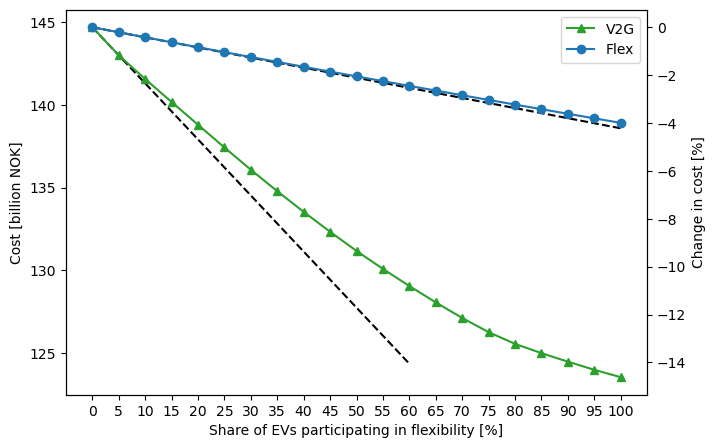

In [10]:
plt.plot(cost_NOK.index.values[:-8], ((((cost_NOK['V2G'][5]-cost_NOK['V2G'][0])/cost_NOK.index.values[1])*cost_NOK.index.values + cost_NOK['V2G'][0])/10**3)[:-8], linestyle='--', color='black')
plt.plot(cost_NOK.index.values, (((cost_NOK['Flex'][5]-cost_NOK['Flex'][0])/cost_NOK.index.values[1])*cost_NOK.index.values + cost_NOK['Flex'][0])/10**3, linestyle='--', color='black')

(cost_NOK/10**3)['V2G'].plot(figsize=(7.5,5), style='-^', color='tab:green', legend=True)
(cost_NOK/10**3)['Flex'].plot(figsize=(7.5,5), style='-o', color='tab:blue', legend=True)

plt.ylabel('Cost [billion NOK]')
# plt.grid()

(((cost_NOK['V2G'] - cost_NOK['V2G'][0])/cost_NOK['V2G'][0])*100).plot(style = '-o', secondary_y = True, markersize = 0, linewidth = 0)
(((cost_NOK['Flex'] - cost_NOK['Flex'][0])/cost_NOK['Flex'][0])*100).plot(style = '-o', secondary_y = True, markersize = 0, linewidth = 0, xlabel='Share of EVs participating in flexibility [%]')

plt.ylabel('Change in cost [%]')


plt.xticks(cost_NOK.index.values)
# plt.savefig('cost.svg', transparent=True, bbox_inches="tight")
plt.show()

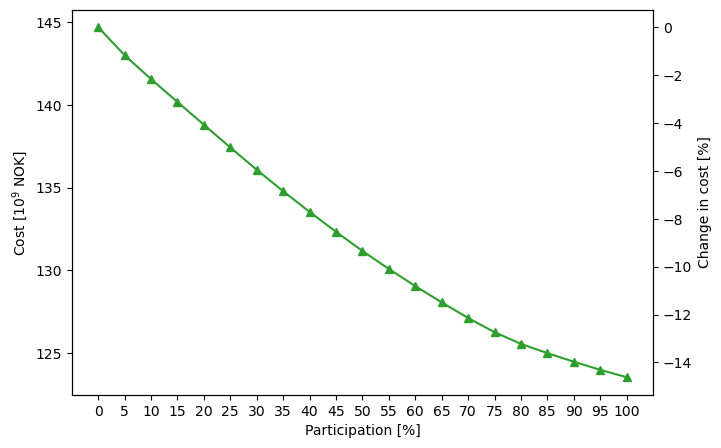

In [18]:
(cost_NOK/10**3)['V2G'].plot(figsize=(7.5,5), style='-^', color='tab:green')

plt.ylabel('Cost [$10^9$ NOK]')

(((cost_NOK['V2G'] - cost_NOK['V2G'][0])/cost_NOK['V2G'][0])*100).plot(style = '-o', secondary_y = True, markersize = 0, linewidth = 0)

plt.ylabel('Change in cost [%]')


plt.xticks(cost_NOK.index.values)
# plt.savefig('cost.jpg', dpi=600, bbox_inches="tight")
plt.show()

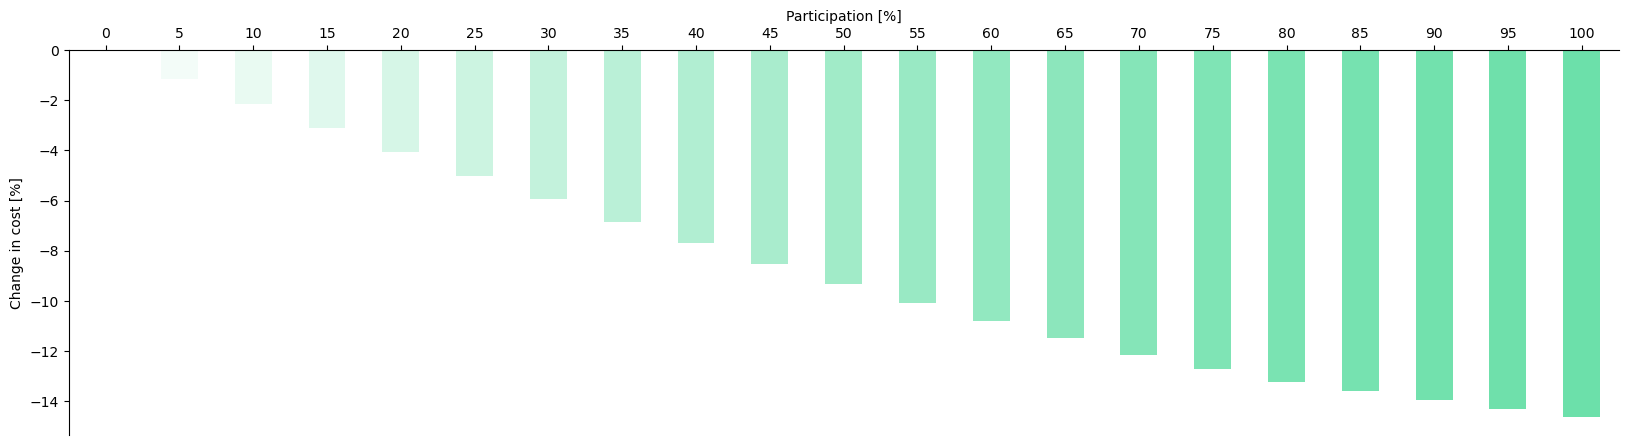

In [19]:
fig, ax = plt.subplots(figsize = (20,5))

data = ((cost_NOK['V2G'] - cost_NOK['V2G'][0])/cost_NOK['V2G'][0])*100

data.plot.bar(xlabel='', color = [(108/256, 225/256, 171/256, abs(x)/abs(data.min())) for x in data])

plt.ylabel('Change in cost [%]')

ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
ax.set_xlabel('Participation [%]')
ax.xaxis.set_label_position('top') 

ax.spines.right.set_visible(False)
ax.spines.bottom.set_visible(False)
# ax.spines.left.set_visible(False)
# ax.spines.top.set_visible(False)

plt.show()

In [20]:
mode = 'V2G'
(((cost_NOK[mode] - cost_NOK[mode][0])/cost_NOK[mode][0])*100)

Participation [%]
0       0.000000
5      -1.171334
10     -2.165480
15     -3.121629
20     -4.074273
25     -5.022279
30     -5.953340
35     -6.848549
40     -7.712054
45     -8.543117
50     -9.343436
55    -10.094704
60    -10.809698
65    -11.493248
70    -12.142974
75    -12.736670
80    -13.225665
85    -13.612878
90    -13.969109
95    -14.308696
100   -14.617889
Name: V2G, dtype: float64

# Capacities

## Generation

In [11]:
cap = makenice(sqlite_list, "cap")

100%|██████████| 42/42 [00:00<00:00, 170.33it/s]


In [12]:
capacity = cap.query("level_1 == 'level' and V2G == 'OFF'").groupby(['participation', 'technology']).sum().rename(columns={'gencaptot':'Flex'})
capacity['V2G'] = cap.query("level_1 == 'level' and V2G == 'ON'").groupby(['participation', 'technology']).sum()

### Solar

In [13]:
solar = capacity.query("technology == 'Solar'").groupby('participation').sum()
solar.index = solar.index.astype(int)
solar = solar.sort_values('participation')
solar.index.names = ['Participation [%]']

In [14]:
(((solar['Flex'] - solar['Flex'][0])/solar['Flex'][0])*100).round(1)

Participation [%]
0       0.0
5      -0.1
10      1.7
15      2.7
20      2.9
25      4.2
30      5.8
35      7.1
40     10.5
45     11.1
50     12.4
55     14.5
60     15.6
65     16.0
70     15.8
75     16.5
80     17.3
85     20.3
90     21.5
95     22.7
100    24.5
Name: Flex, dtype: float64

In [21]:
(((solar['V2G'] - solar['V2G'][0])/solar['V2G'][0])*100).round(1)

Participation [%]
0       0.0
5      -6.0
10     -5.3
15     -3.8
20     -3.0
25     -1.6
30      3.3
35      9.9
40     14.8
45     21.2
50     28.0
55     32.7
60     34.4
65     35.8
70     37.4
75     32.5
80     16.6
85     10.9
90      8.8
95     21.6
100    33.1
Name: V2G, dtype: float64

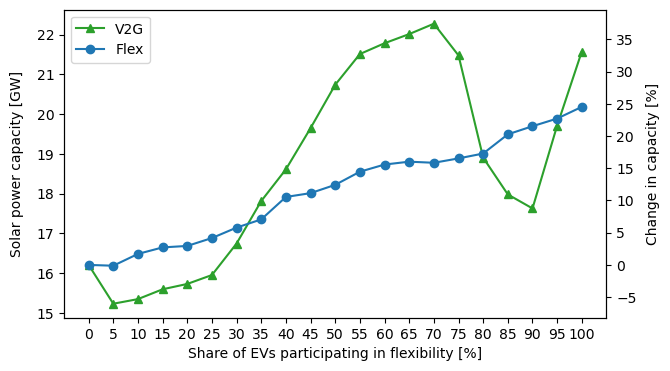

In [24]:
solar['V2G'].plot(figsize=(7,4), style='-^', color='tab:green', legend=True)
solar['Flex'].plot(style='-o', color='tab:blue', legend=True)
# plt.ylim(15,22.5)
plt.ylabel('Solar power capacity [GW]', labelpad=9)

# plt.grid()

(((solar['V2G'] - solar['V2G'][0])/solar['V2G'][0])*100).plot(secondary_y=True, linewidth = 0)
(((solar['Flex'] - solar['Flex'][0])/solar['Flex'][0])*100).plot(secondary_y=True, linewidth = 0, xlabel='Share of EVs participating in flexibility [%]')
plt.yticks(ticks=[-5,0,5,10,15,20,25,30,35])

plt.ylabel('Change in capacity [%]', labelpad=7)

plt.xticks(solar.index.values)

# plt.savefig('solar.svg', transparent=True, bbox_inches="tight")

plt.show()

In [25]:
mode = 'Flex'
solar[mode][100] - solar[mode][0]

np.float64(3.9741704718069677)

In [26]:
((solar['V2G'] - solar['V2G'][0])/solar['V2G'][0])*100

Participation [%]
0       0.000000
5      -6.020756
10     -5.304277
15     -3.779430
20     -2.950810
25     -1.569771
30      3.322019
35      9.915680
40     14.830276
45     21.224130
50     27.952654
55     32.717206
60     34.393735
65     35.815351
70     37.421210
75     32.501423
80     16.638837
85     10.933817
90      8.764231
95     21.615217
100    33.110952
Name: V2G, dtype: float64

In [27]:
colours = {'Onshore':'#8ac48a', 'Fixed offshore':'#a7baf1', 'Floating offshore':'#8a8ae8'}
edgecolours = {'Onshore':'#008000', 'Fixed offshore':'#4169e1', 'Floating offshore':'#0000cd'}

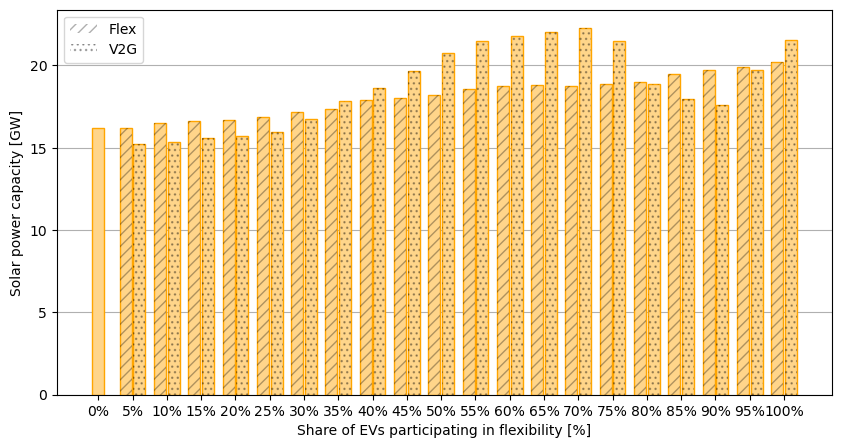

In [28]:
barwidth = 0.35
buffer = 0.025

fig, ax = plt.subplots(figsize = (10,5))

xticks = (pd.Series(np.linspace(0, 100, 21, dtype=int)).astype(str) + '%').values

plt.bar(barwidth/2, solar.Flex[0], width = barwidth, color='#ffd58a', edgecolor='#ffa500', zorder=2)

plt.bar(np.arange(len(xticks))[1:]-buffer, solar.Flex[1:], width = barwidth, color='#ffd58a', edgecolor='#ffa500', zorder=2)
a = plt.bar(np.arange(len(xticks))[1:]-buffer, solar.Flex[1:], width = barwidth, color='#ffd58a00', edgecolor='#00000050', zorder=2, hatch='///', linewidth=0)

plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, solar.V2G[1:], width = barwidth, color='#ffd58a', edgecolor='#ffa500', zorder=2)
b = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, solar.V2G[1:], width = barwidth, color='#ffd58a00', edgecolor='#00000050', zorder=2, hatch='...', linewidth=0)

plt.legend([a,b],['Flex', 'V2G']) # , bbox_to_anchor=(1,0.3525))

plt.xticks(np.arange(len(xticks)) + barwidth/2, xticks)

plt.ylabel('Solar power capacity [GW]')
plt.xlabel('Share of EVs participating in flexibility [%]')
plt.grid(axis='y')
plt.show()

### Fixed offshore wind

In [15]:
offshore_bottom = capacity.query("technology == 'Windoffshore'").groupby('participation').sum()
offshore_bottom.index = offshore_bottom.index.astype(int)
offshore_bottom = offshore_bottom.sort_values('participation')
offshore_bottom.index.names = ['Participation [%]']

In [24]:
(((offshore_bottom['Flex'] - offshore_bottom['Flex'][0])/offshore_bottom['Flex'][0])*100).round(1)

Participation [%]
0      0.0
5      0.6
10    -0.2
15    -0.8
20    -1.4
25    -2.0
30    -2.7
35    -3.6
40    -4.1
45    -2.7
50    -1.7
55    -1.2
60    -1.0
65    -1.1
70    -0.3
75    -0.1
80     0.4
85    -0.4
90    -0.7
95    -0.3
100    1.1
Name: Flex, dtype: float64

In [26]:
(((offshore_bottom['V2G'] - offshore_bottom['V2G'][0])/offshore_bottom['V2G'][0])*100).round(1)

Participation [%]
0       0.0
5      -3.7
10      5.2
15      3.6
20      2.8
25      1.0
30     -3.1
35     -5.8
40     -9.8
45    -11.7
50    -12.0
55     -9.8
60     -4.1
65      1.8
70      8.0
75     12.9
80     21.4
85     30.7
90     40.3
95     39.3
100    37.8
Name: V2G, dtype: float64

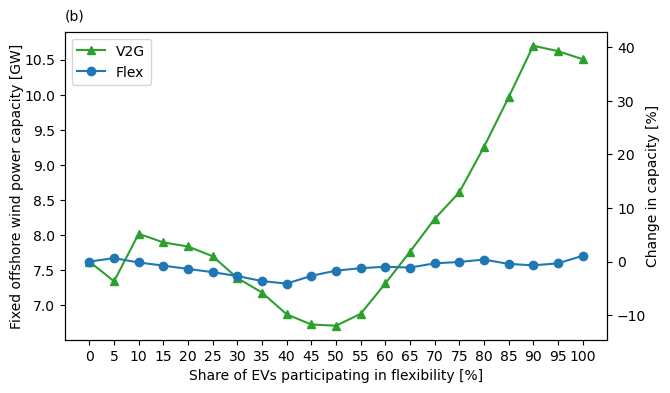

In [30]:
offshore_bottom['V2G'].plot(figsize=(7,4), style='-^', color='tab:green', legend=True)
offshore_bottom['Flex'].plot(style='-o', color='tab:blue', legend=True)
plt.ylabel('Fixed offshore wind power capacity [GW]', labelpad=0)

# plt.grid()

(((offshore_bottom['V2G'] - offshore_bottom['V2G'][0])/offshore_bottom['V2G'][0])*100).plot(secondary_y=True, linewidth = 0)
(((offshore_bottom['Flex'] - offshore_bottom['Flex'][0])/offshore_bottom['Flex'][0])*100).plot(secondary_y=True, linewidth = 0, xlabel='Share of EVs participating in flexibility [%]')
plt.yticks(ticks=[-10,0,10,20,30,40])

plt.ylabel('Change in capacity [%]', labelpad=0)

plt.xticks(offshore_bottom.index.values)

plt.text(-5,45,'(b)')

# plt.savefig('fixed_offshore_wind.svg', transparent=True, bbox_inches="tight")

plt.show()

In [31]:
mode = 'V2G'
((offshore_bottom[mode] - offshore_bottom[mode][0])/offshore_bottom[mode][0])*100

Participation [%]
0       0.000000
5      -3.682638
10      5.193821
15      3.576083
20      2.819514
25      0.992416
30     -3.068075
35     -5.781301
40     -9.846849
45    -11.742241
50    -11.976849
55     -9.758245
60     -4.090549
65      1.826029
70      7.974237
75     12.926446
80     21.391224
85     30.671349
90     40.312367
95     39.302021
100    37.795495
Name: V2G, dtype: float64

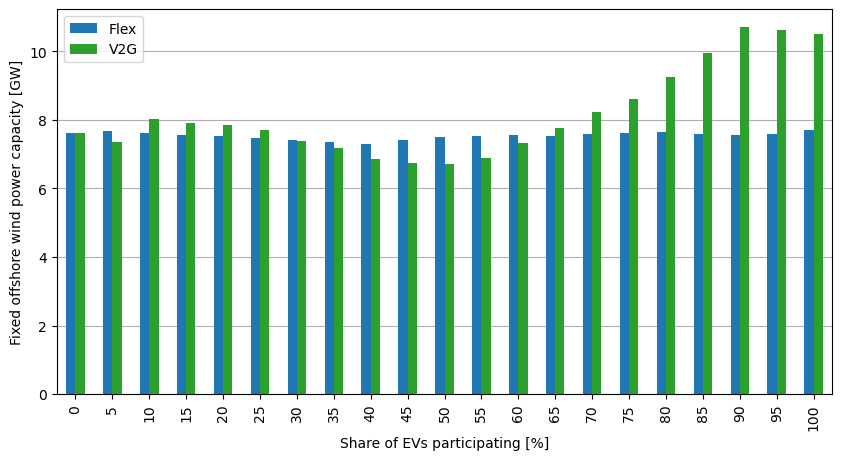

In [32]:
offshore_bottom.plot.bar(figsize=(10,5), zorder=2, color={'V2G':'tab:green','Flex':'tab:blue'})
plt.ylabel('Fixed offshore wind power capacity [GW]')
plt.xlabel('Share of EVs participating [%]')
plt.grid(axis='y')
plt.show()

### Floating offshore wind

In [16]:
offshore_floating = capacity.query("technology == 'Windoffshorefloating'").groupby('participation').sum()
offshore_floating.index = offshore_floating.index.astype(int)
offshore_floating = offshore_floating.sort_values('participation')
offshore_floating.index.names = ['Participation [%]']

In [29]:
(((offshore_floating['Flex'] - offshore_floating['Flex'][0])/offshore_floating['Flex'][0])*100).round(1)

Participation [%]
0      0.0
5     -0.3
10    -0.8
15    -1.2
20    -1.6
25    -2.3
30    -2.7
35    -3.0
40    -3.5
45    -3.9
50    -4.3
55    -4.5
60    -5.0
65    -5.5
70    -6.0
75    -6.6
80    -7.0
85    -7.6
90    -7.9
95    -8.3
100   -9.0
Name: Flex, dtype: float64

In [31]:
(((offshore_floating['V2G'] - offshore_floating['V2G'][0])/offshore_floating['V2G'][0])*100).round(1)

Participation [%]
0       0.0
5      -0.1
10     -0.2
15      0.1
20      0.5
25      0.3
30      0.1
35     -0.6
40     -1.2
45     -1.2
50      0.0
55      0.7
60     -3.5
65     -5.8
70     -9.5
75    -13.4
80    -16.2
85    -20.8
90    -25.0
95    -28.9
100   -33.6
Name: V2G, dtype: float64

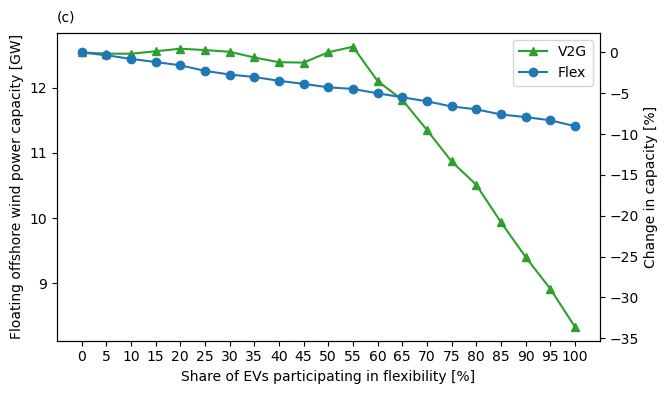

In [34]:
offshore_floating['V2G'].plot(figsize=(7,4), style='-^', color='tab:green', legend=True)
offshore_floating['Flex'].plot(style='-o', color='tab:blue', legend=True)
plt.ylabel('Floating offshore wind power capacity [GW]')

# plt.grid()

(((offshore_floating['V2G'] - offshore_floating['V2G'][0])/offshore_floating['V2G'][0])*100).plot(secondary_y=True, linewidth = 0)
(((offshore_floating['Flex'] - offshore_floating['Flex'][0])/offshore_floating['Flex'][0])*100).plot(secondary_y=True, linewidth = 0, xlabel='Share of EVs participating in flexibility [%]')

plt.ylabel('Change in capacity [%]')

plt.xticks(offshore_floating.index.values)

plt.text(-5,3.85,'(c)')

# plt.savefig('floating_offshore_wind.svg', transparent=True, bbox_inches="tight")

plt.show()

In [35]:
mode = 'V2G'
((offshore_floating[mode] - offshore_floating[mode][0])/offshore_floating[mode][0])*100

Participation [%]
0       0.000000
5      -0.142657
10     -0.160384
15      0.142625
20      0.455967
25      0.287043
30      0.078981
35     -0.617963
40     -1.198089
45     -1.243328
50      0.020069
55      0.699320
60     -3.500037
65     -5.800223
70     -9.486516
75    -13.350370
80    -16.201224
85    -20.774916
90    -25.039866
95    -28.928655
100   -33.582488
Name: V2G, dtype: float64

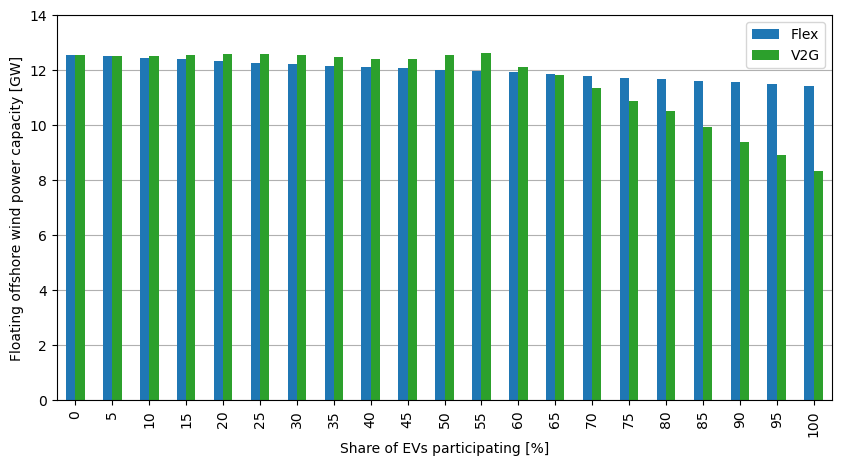

In [36]:
offshore_floating.plot.bar(figsize=(10,5), zorder=2, color={'V2G':'tab:green','Flex':'tab:blue'}, alpha=1)
plt.ylim(0,14)
plt.ylabel('Floating offshore wind power capacity [GW]')
plt.xlabel('Share of EVs participating [%]')
plt.grid(axis='y')
plt.show()

### Onshore wind

In [17]:
onshore = capacity.query("technology == 'Windonshore'").groupby('participation').sum()
onshore.index = onshore.index.astype(int)
onshore = onshore.sort_values('participation')
onshore.index.names = ['Participation [%]']

In [34]:
(((onshore['Flex'] - onshore['Flex'][0])/onshore['Flex'][0])*100).round(1)

Participation [%]
0      0.0
5     -0.4
10    -0.0
15     0.3
20     1.0
25     1.8
30     2.2
35     2.5
40     1.8
45     0.3
50    -0.9
55    -2.2
60    -2.3
65    -1.9
70    -2.0
75    -1.7
80    -2.2
85    -1.9
90    -1.9
95    -2.5
100   -3.8
Name: Flex, dtype: float64

In [36]:
(((onshore['V2G'] - onshore['V2G'][0])/onshore['V2G'][0])*100).round(1)

Participation [%]
0       0.0
5      10.6
10      2.6
15      2.9
20      3.0
25      4.8
30      6.6
35      8.3
40     11.9
45     11.3
50      4.2
55     -5.1
60     -8.5
65    -15.3
70    -19.8
75    -20.1
80    -22.4
85    -25.1
90    -29.8
95    -26.7
100   -21.0
Name: V2G, dtype: float64

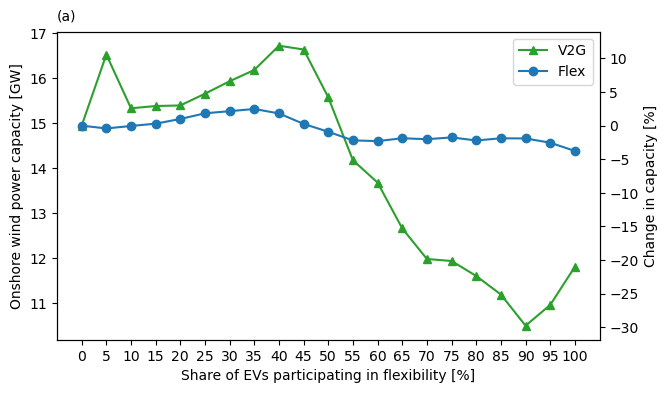

In [38]:
onshore['V2G'].plot(figsize=(7,4), style='-^', color='tab:green', legend=True)
onshore['Flex'].plot(style='-o', color='tab:blue', legend=True)
plt.ylabel('Onshore wind power capacity [GW]')

# plt.grid()

(((onshore['V2G'] - onshore['V2G'][0])/onshore['V2G'][0])*100).plot(secondary_y=True, linewidth = 0)
(((onshore['Flex'] - onshore['Flex'][0])/onshore['Flex'][0])*100).plot(secondary_y=True, linewidth = 0, xlabel='Share of EVs participating in flexibility [%]')
plt.yticks(ticks=[-30,-25,-20,-15,-10,-5,0,5,10])
plt.ylabel('Change in capacity [%]')

plt.xticks(onshore.index.values)

plt.text(-5,15.6,'(a)')

# plt.savefig('onshore_wind.svg', transparent=True, bbox_inches="tight")

plt.show()

In [39]:
mode = 'V2G'
((onshore[mode] - onshore[mode][0])/onshore[mode][0])*100

Participation [%]
0       0.000000
5      10.583932
10      2.585160
15      2.921181
20      3.008759
25      4.754691
30      6.611045
35      8.289314
40     11.896184
45     11.333255
50      4.213305
55     -5.147558
60     -8.478288
65    -15.291866
70    -19.844644
75    -20.139665
80    -22.373726
85    -25.129659
90    -29.773802
95    -26.679689
100   -21.001456
Name: V2G, dtype: float64

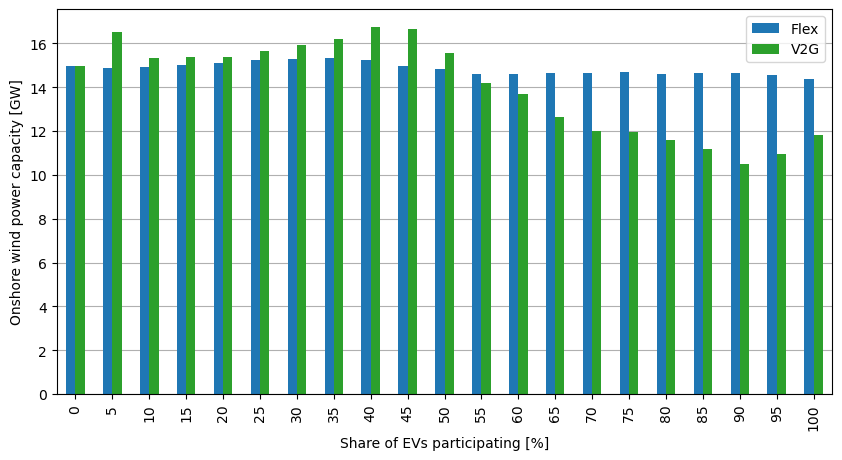

In [40]:
onshore.plot.bar(figsize=(10,5), zorder=2, color={'V2G':'tab:green','Flex':'tab:blue'}, alpha=1)
plt.ylabel('Onshore wind power capacity [GW]')
plt.xlabel('Share of EVs participating [%]')
plt.grid(axis='y')
plt.show()

### Total wind

In [18]:
wind = onshore + offshore_bottom + offshore_floating

In [45]:
(((wind['Flex'] - wind['Flex'][0])/wind['Flex'][0])*100).round(1)

Participation [%]
0      0.0
5     -0.2
10    -0.3
15    -0.5
20    -0.4
25    -0.5
30    -0.6
35    -0.8
40    -1.4
45    -1.8
50    -2.3
55    -2.8
60    -3.0
65    -3.0
70    -3.1
75    -3.1
80    -3.3
85    -3.6
90    -3.8
95    -4.1
100   -4.6
Name: Flex, dtype: float64

In [46]:
(((wind['V2G'] - wind['V2G'][0])/wind['V2G'][0])*100).round(1)

Participation [%]
0       0.0
5       3.7
10      2.2
15      2.1
20      2.1
25      2.3
30      2.2
35      2.1
40      2.5
45      1.8
50     -0.8
55     -4.1
60     -5.7
65     -8.2
70    -10.1
75    -10.5
80    -10.7
85    -11.5
90    -12.9
95    -13.2
100   -12.7
Name: V2G, dtype: float64

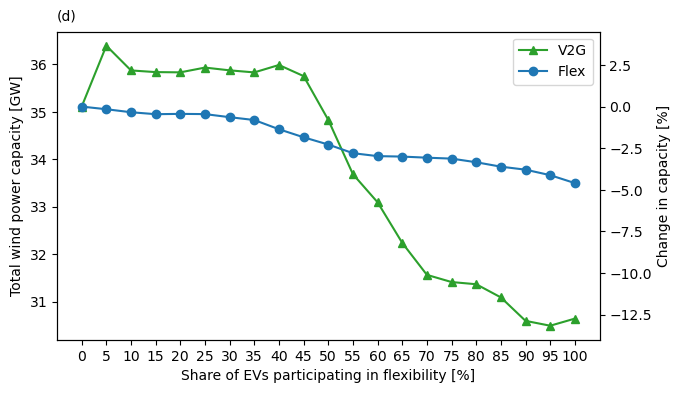

In [ ]:
wind['V2G'].plot(figsize=(7,4), style='-^', color='tab:green', legend=True)
wind['Flex'].plot(style='-o', color='tab:blue', legend=True)
plt.ylabel('Total wind power capacity [GW]')

# plt.grid()

(((wind['V2G'] - wind['V2G'][0])/wind['V2G'][0])*100).plot(secondary_y=True, linewidth = 0)
(((wind['Flex'] - wind['Flex'][0])/wind['Flex'][0])*100).plot(secondary_y=True, linewidth = 0, xlabel='Share of EVs participating in flexibility [%]')
#plt.yticks(ticks=[-30,-25,-20,-15,-10,-5,0,5,10])
plt.ylabel('Change in capacity [%]')

plt.xticks(wind.index.values)

plt.text(-5,5.15,'(d)')

# plt.savefig('total_wind.svg', transparent=True, bbox_inches="tight")

plt.show()

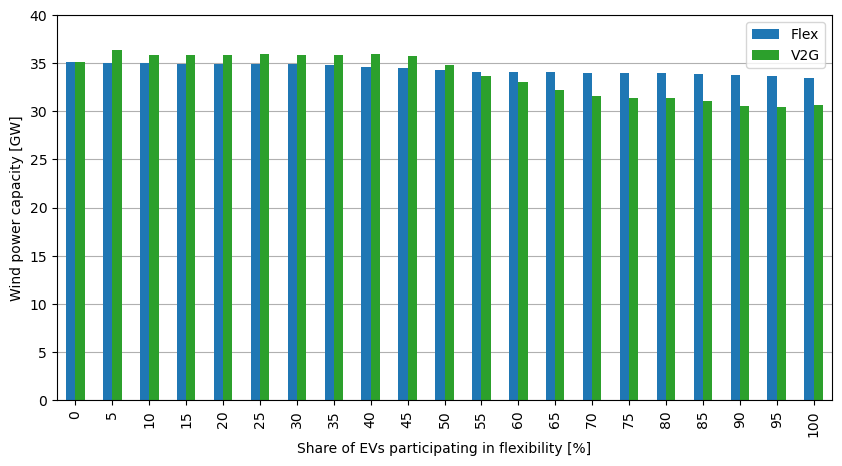

In [43]:
wind.plot.bar(figsize=(10,5), zorder=2, color={'V2G':'tab:green','Flex':'tab:blue'}, alpha=1)
plt.ylim(0,40)
plt.ylabel('Wind power capacity [GW]')
plt.xlabel('Share of EVs participating in flexibility [%]')
plt.grid(axis='y')
plt.show()

### Total VRE

#### Flex

In [19]:
gen_V2G_off = pd.DataFrame()
gen_V2G_off['Onshore'] = onshore['Flex']
gen_V2G_off['Fixed offshore'] = offshore_bottom['Flex']
gen_V2G_off['Floating offshore'] = offshore_floating['Flex']
gen_V2G_off['Solar'] = solar['Flex']

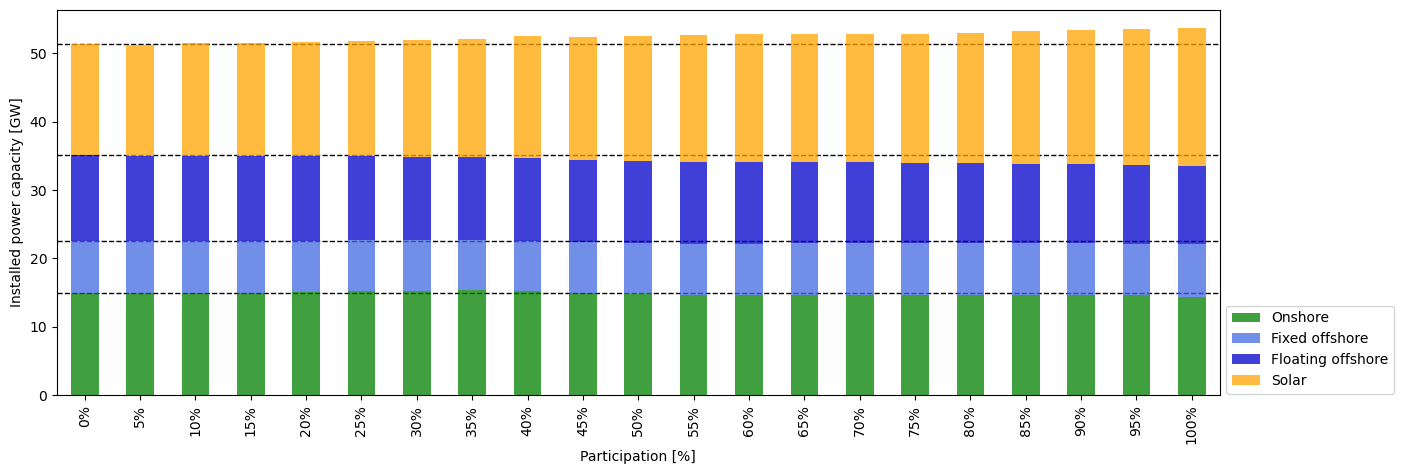

In [46]:
fig, ax = plt.subplots(figsize = (15,5))

colours = {'Onshore':'#008000', 'Fixed offshore':'#4169e1', 'Floating offshore':'#0000cd', 'Solar':'#ffa500'}

gen_V2G_off.plot.bar(stacked=True, color=colours, alpha=0.75, ax=ax, zorder=2)

plt.xlabel('Participation [%]')
plt.ylabel('Installed power capacity [GW]')

xticks = (pd.Series(np.linspace(0, 100, 21, dtype=int)).astype(str) + '%').values
plt.xticks(np.arange(len(xticks)), xticks)

plt.legend(['Onshore', 'Fixed offshore', 'Floating offshore', 'Solar'], bbox_to_anchor=(1,0.25))

ax.axhline(gen_V2G_off.loc[0,'Onshore'], linestyle='--', linewidth=1, color='black', zorder=1)
ax.axhline(gen_V2G_off.loc[0,'Onshore'] + gen_V2G_off.loc[0,'Fixed offshore'], linestyle='--', linewidth=1, color='black', zorder=1)
ax.axhline(gen_V2G_off.loc[0,'Onshore'] + gen_V2G_off.loc[0,'Fixed offshore'] + gen_V2G_off.loc[0,'Floating offshore'], linestyle='--', linewidth=1, color='black', zorder=1)
ax.axhline(gen_V2G_off.loc[0,'Onshore'] + gen_V2G_off.loc[0,'Fixed offshore'] + gen_V2G_off.loc[0,'Floating offshore'] + gen_V2G_off.loc[0,'Solar'], linestyle='--', linewidth=1, color='black', zorder=1)

plt.show()

#### V2G

In [20]:
gen_V2G_on = pd.DataFrame()
gen_V2G_on['Onshore'] = onshore['V2G']
gen_V2G_on['Fixed offshore'] = offshore_bottom['V2G']
gen_V2G_on['Floating offshore'] = offshore_floating['V2G']
gen_V2G_on['Solar'] = solar['V2G']

<Axes: xlabel='Participation [%]'>

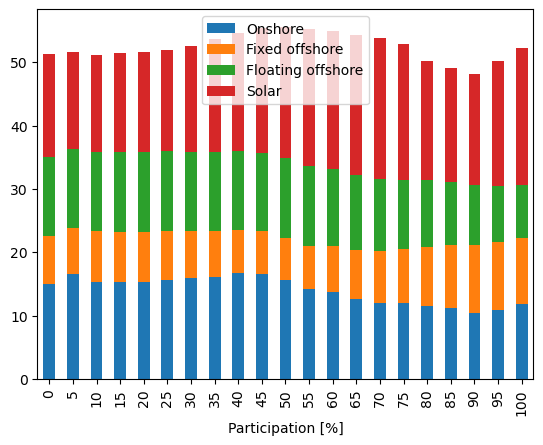

In [48]:
gen_V2G_on.plot.bar(stacked=True)

#### Flex and V2G in same plot

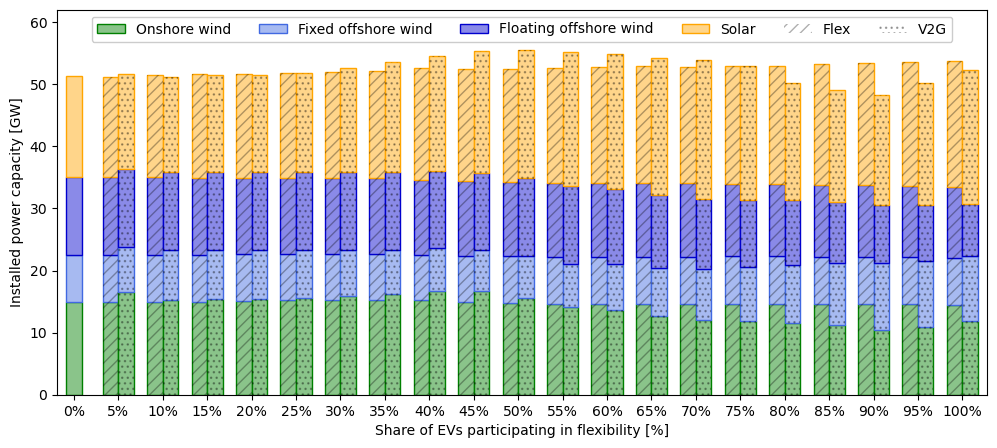

In [49]:
# colours = {'Onshore':'#00800075', 'Fixed offshore':'#4169e175', 'Floating offshore':'#0000cd75', 'Solar':'#ffa50075'}
colours = {'Onshore':'#8ac48a', 'Fixed offshore':'#a7baf1', 'Floating offshore':'#8a8ae8', 'Solar':'#ffd58a'}
edgecolours = {'Onshore':'#008000', 'Fixed offshore':'#4169e1', 'Floating offshore':'#0000cd', 'Solar':'#ffa500'}

xticks = (pd.Series(np.linspace(0, 100, 21, dtype=int)).astype(str) + '%').values

barwidth = 0.35
buffer = 0

fig, ax = plt.subplots(figsize = (12,5))

plt.bar(barwidth/2, gen_V2G_off.loc[0,'Onshore'], width = barwidth, edgecolor=edgecolours.get('Onshore'), color=colours.get('Onshore'), zorder=2)
plt.bar(barwidth/2, gen_V2G_off.loc[0,'Fixed offshore'], width = barwidth, bottom=gen_V2G_off.loc[0,'Onshore'], edgecolor=edgecolours.get('Fixed offshore'), color=colours.get('Fixed offshore'), zorder=2)
plt.bar(barwidth/2, gen_V2G_off.loc[0,'Floating offshore'], width = barwidth, bottom=gen_V2G_off.loc[0,'Onshore']+gen_V2G_off.loc[0,'Fixed offshore'], edgecolor=edgecolours.get('Floating offshore'), color=colours.get('Floating offshore'), zorder=2)
plt.bar(barwidth/2, gen_V2G_off.loc[0,'Solar'], width = barwidth, bottom=gen_V2G_off.loc[0,'Onshore']+gen_V2G_off.loc[0,'Fixed offshore']+gen_V2G_off.loc[0,'Floating offshore'], edgecolor=edgecolours.get('Solar'), color=colours.get('Solar'), zorder=2)

plt.bar(np.arange(len(xticks))[1:]-buffer, gen_V2G_off.loc[1:,'Onshore'], width = barwidth, edgecolor=edgecolours.get('Onshore'), color=colours.get('Onshore'), zorder=2)
plt.bar(np.arange(len(xticks))[1:]-buffer, gen_V2G_off.loc[1:,'Fixed offshore'], width = barwidth, bottom=gen_V2G_off.loc[1:,'Onshore'], edgecolor=edgecolours.get('Fixed offshore'), color=colours.get('Fixed offshore'), zorder=2)
plt.bar(np.arange(len(xticks))[1:]-buffer, gen_V2G_off.loc[1:,'Floating offshore'], width = barwidth, bottom=gen_V2G_off.loc[1:,'Onshore']+gen_V2G_off.loc[1:,'Fixed offshore'], edgecolor=edgecolours.get('Floating offshore'), color=colours.get('Floating offshore'), zorder=2)
plt.bar(np.arange(len(xticks))[1:]-buffer, gen_V2G_off.loc[1:,'Solar'], width = barwidth, bottom=gen_V2G_off.loc[1:,'Onshore']+gen_V2G_off.loc[1:,'Fixed offshore']+gen_V2G_off.loc[1:,'Floating offshore'], edgecolor=edgecolours.get('Solar'), color=colours.get('Solar'), zorder=2)

a = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, gen_V2G_on.loc[1:,'Onshore'], width = barwidth, edgecolor=edgecolours.get('Onshore'), color=colours.get('Onshore'), zorder=2)
b = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, gen_V2G_on.loc[1:,'Fixed offshore'], width = barwidth, bottom=gen_V2G_on.loc[1:,'Onshore'], edgecolor=edgecolours.get('Fixed offshore'), color=colours.get('Fixed offshore'), zorder=2)
c = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, gen_V2G_on.loc[1:,'Floating offshore'], width = barwidth, bottom=gen_V2G_on.loc[1:,'Onshore']+gen_V2G_on.loc[1:,'Fixed offshore'], edgecolor=edgecolours.get('Floating offshore'), color=colours.get('Floating offshore'), zorder=2)
d = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, gen_V2G_on.loc[1:,'Solar'], width = barwidth, bottom=gen_V2G_on.loc[1:,'Onshore']+gen_V2G_on.loc[1:,'Fixed offshore']+gen_V2G_on.loc[1:,'Floating offshore'], edgecolor=edgecolours.get('Solar'), color=colours.get('Solar'), zorder=2)

e = plt.bar(np.arange(len(xticks))[1:]-buffer, gen_V2G_off.loc[1:].T.sum(), width = barwidth, edgecolor='#00000050', color='#00000000', linewidth=0, zorder=2, hatch='///')
f = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, gen_V2G_on.loc[1:].T.sum(), width = barwidth, edgecolor='#00000050', color='#00000000', linewidth=0, zorder=2, hatch='...')

plt.legend([a,b,c,d,e,f],['Onshore wind', 'Fixed offshore wind', 'Floating offshore wind', 'Solar', 'Flex', 'V2G'], loc='upper center', ncols=6, framealpha=1)

# ax.axhline(gen_V2G_off.loc[0,'Onshore'], linestyle='--', linewidth=1, color='black', zorder=1)
# ax.axhline(gen_V2G_off.loc[0,'Onshore'] + gen_V2G_off.loc[0,'Fixed offshore'], linestyle='--', linewidth=1, color='black', zorder=1)
# ax.axhline(gen_V2G_off.loc[0,'Onshore'] + gen_V2G_off.loc[0,'Fixed offshore'] + gen_V2G_off.loc[0,'Floating offshore'], linestyle='--', linewidth=1, color='black', zorder=1)
# ax.axhline(gen_V2G_off.loc[0,'Onshore'] + gen_V2G_off.loc[0,'Fixed offshore'] + gen_V2G_off.loc[0,'Floating offshore'] + gen_V2G_off.loc[0,'Solar'], linestyle='--', linewidth=1, color='black', zorder=1)

# plt.grid(axis='y')

plt.xticks(np.arange(len(xticks)) + barwidth/2, xticks)

plt.ylim(0,62)

plt.xlabel('Share of EVs participating in flexibility [%]')
plt.ylabel('Installed power capacity [GW]')

ax.margins(x=0.01)

# plt.savefig('cap.svg', transparent=True, bbox_inches="tight")

plt.show()

##### Version with only selected scenarios

In [50]:
# select only certain scenarios to make plot easier to read
scenarios = [0,10,20,30,40,50,60,70,80,90,100]
gen_V2G_off_sel = gen_V2G_off.loc[scenarios]
gen_V2G_on_sel = gen_V2G_on.loc[scenarios]

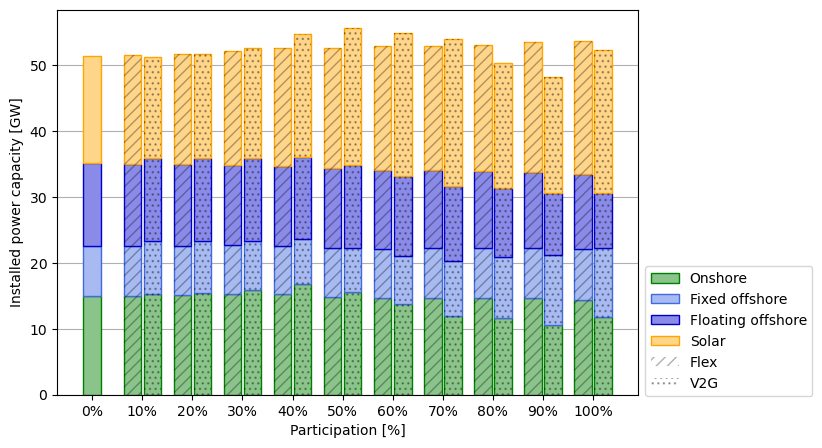

In [51]:
# colours = {'Onshore':'#00800075', 'Fixed offshore':'#4169e175', 'Floating offshore':'#0000cd75', 'Solar':'#ffa50075'}
colours = {'Onshore':'#8ac48a', 'Fixed offshore':'#a7baf1', 'Floating offshore':'#8a8ae8', 'Solar':'#ffd58a'}
edgecolours = {'Onshore':'#008000', 'Fixed offshore':'#4169e1', 'Floating offshore':'#0000cd', 'Solar':'#ffa500'}
# edgecolours = {'Onshore':'#00000000', 'Fixed offshore':'#00000000', 'Floating offshore':'#00000000', 'Solar':'#00000000'}

xticks = (pd.Series(np.array(scenarios, dtype=int)).astype(str) + '%').values

barwidth = 0.35
buffer = 0.025

fig, ax = plt.subplots(figsize = (7.5,5))

plt.bar(barwidth/2, gen_V2G_off_sel.loc[0,'Onshore'], width = barwidth, edgecolor=edgecolours.get('Onshore'), color=colours.get('Onshore'), zorder=2)
plt.bar(barwidth/2, gen_V2G_off_sel.loc[0,'Fixed offshore'], width = barwidth, bottom=gen_V2G_off_sel.loc[0,'Onshore'], edgecolor=edgecolours.get('Fixed offshore'), color=colours.get('Fixed offshore'), zorder=2)
plt.bar(barwidth/2, gen_V2G_off_sel.loc[0,'Floating offshore'], width = barwidth, bottom=gen_V2G_off_sel.loc[0,'Onshore']+gen_V2G_off_sel.loc[0,'Fixed offshore'], edgecolor=edgecolours.get('Floating offshore'), color=colours.get('Floating offshore'), zorder=2)
plt.bar(barwidth/2, gen_V2G_off_sel.loc[0,'Solar'], width = barwidth, bottom=gen_V2G_off_sel.loc[0,'Onshore']+gen_V2G_off_sel.loc[0,'Fixed offshore']+gen_V2G_off_sel.loc[0,'Floating offshore'], edgecolor=edgecolours.get('Solar'), color=colours.get('Solar'), zorder=2)

plt.bar(np.arange(len(xticks))[1:]-buffer, gen_V2G_off_sel.loc[1:,'Onshore'], width = barwidth, edgecolor=edgecolours.get('Onshore'), color=colours.get('Onshore'), zorder=2)
plt.bar(np.arange(len(xticks))[1:]-buffer, gen_V2G_off_sel.loc[1:,'Fixed offshore'], width = barwidth, bottom=gen_V2G_off_sel.loc[1:,'Onshore'], edgecolor=edgecolours.get('Fixed offshore'), color=colours.get('Fixed offshore'), zorder=2)
plt.bar(np.arange(len(xticks))[1:]-buffer, gen_V2G_off_sel.loc[1:,'Floating offshore'], width = barwidth, bottom=gen_V2G_off_sel.loc[1:,'Onshore']+gen_V2G_off_sel.loc[1:,'Fixed offshore'], edgecolor=edgecolours.get('Floating offshore'), color=colours.get('Floating offshore'), zorder=2)
plt.bar(np.arange(len(xticks))[1:]-buffer, gen_V2G_off_sel.loc[1:,'Solar'], width = barwidth, bottom=gen_V2G_off_sel.loc[1:,'Onshore']+gen_V2G_off_sel.loc[1:,'Fixed offshore']+gen_V2G_off_sel.loc[1:,'Floating offshore'], edgecolor=edgecolours.get('Solar'), color=colours.get('Solar'), zorder=2)

a = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, gen_V2G_on_sel.loc[1:,'Onshore'], width = barwidth, edgecolor=edgecolours.get('Onshore'), color=colours.get('Onshore'), zorder=2)
b = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, gen_V2G_on_sel.loc[1:,'Fixed offshore'], width = barwidth, bottom=gen_V2G_on_sel.loc[1:,'Onshore'], edgecolor=edgecolours.get('Fixed offshore'), color=colours.get('Fixed offshore'), zorder=2)
c = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, gen_V2G_on_sel.loc[1:,'Floating offshore'], width = barwidth, bottom=gen_V2G_on_sel.loc[1:,'Onshore']+gen_V2G_on_sel.loc[1:,'Fixed offshore'], edgecolor=edgecolours.get('Floating offshore'), color=colours.get('Floating offshore'), zorder=2)
d = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, gen_V2G_on_sel.loc[1:,'Solar'], width = barwidth, bottom=gen_V2G_on_sel.loc[1:,'Onshore']+gen_V2G_on_sel.loc[1:,'Fixed offshore']+gen_V2G_on_sel.loc[1:,'Floating offshore'], edgecolor=edgecolours.get('Solar'), color=colours.get('Solar'), zorder=2)

e = plt.bar(np.arange(len(xticks))[1:]-buffer, gen_V2G_off_sel.loc[1:].T.sum(), width = barwidth, edgecolor='#00000050', color='#00000000', linewidth=0, zorder=2, hatch='///')
f = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, gen_V2G_on_sel.loc[1:].T.sum(), width = barwidth, edgecolor='#00000050', color='#00000000', linewidth=0, zorder=2, hatch='...')

plt.legend([a,b,c,d,e,f],['Onshore', 'Fixed offshore', 'Floating offshore', 'Solar', 'Flex', 'V2G'], bbox_to_anchor=(1,0.3525))

# ax.axhline(gen_V2G_off_sel.loc[0,'Onshore'], linestyle='--', linewidth=1, color='black', zorder=1)
# ax.axhline(gen_V2G_off_sel.loc[0,'Onshore'] + gen_V2G_off_sel.loc[0,'Fixed offshore'], linestyle='--', linewidth=1, color='black', zorder=1)
# ax.axhline(gen_V2G_off_sel.loc[0,'Onshore'] + gen_V2G_off_sel.loc[0,'Fixed offshore'] + gen_V2G_off_sel.loc[0,'Floating offshore'], linestyle='--', linewidth=1, color='black', zorder=1)
# ax.axhline(gen_V2G_off_sel.loc[0,'Onshore'] + gen_V2G_off_sel.loc[0,'Fixed offshore'] + gen_V2G_off_sel.loc[0,'Floating offshore'] + gen_V2G_off_sel.loc[0,'Solar'], linestyle='--', linewidth=1, color='black', zorder=1)

plt.grid(axis='y')

plt.xticks(np.arange(len(xticks)) + barwidth/2, xticks)

plt.xlabel('Participation [%]')
plt.ylabel('Installed power capacity [GW]')

plt.show()

##### Horizontal version

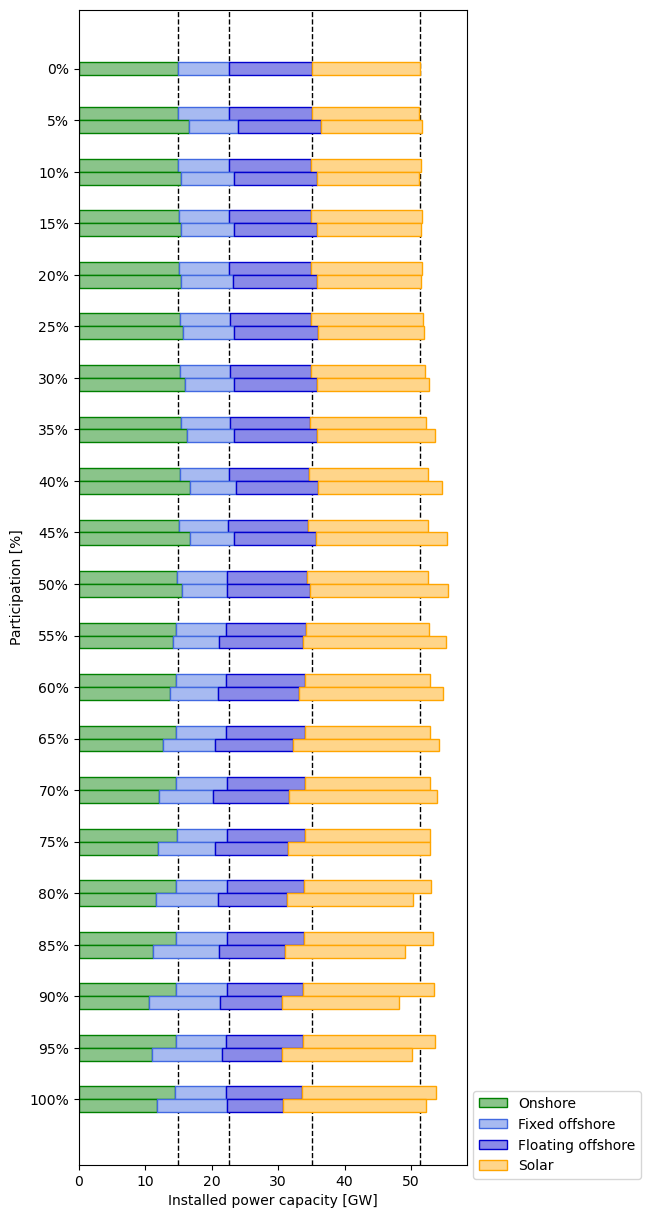

In [52]:
# colours = {'Onshore':'#00800075', 'Fixed offshore':'#4169e175', 'Floating offshore':'#0000cd75', 'Solar':'#ffa50075'}
colours = {'Onshore':'#8ac48a', 'Fixed offshore':'#a7baf1', 'Floating offshore':'#8a8ae8', 'Solar':'#ffd58a'}
edgecolours = {'Onshore':'#008000', 'Fixed offshore':'#4169e1', 'Floating offshore':'#0000cd', 'Solar':'#ffa500'}

yticks = (pd.Series(np.linspace(0, 100, 21, dtype=int)).astype(str) + '%').values

barheight = 0.25

fig, ax = plt.subplots(figsize = (5,15))

plt.barh(barheight/2, gen_V2G_off.loc[0,'Onshore'], height = barheight, edgecolor=edgecolours.get('Onshore'), color=colours.get('Onshore'), zorder=2)
plt.barh(barheight/2, gen_V2G_off.loc[0,'Fixed offshore'], height = barheight, left=gen_V2G_off.loc[0,'Onshore'], edgecolor=edgecolours.get('Fixed offshore'), color=colours.get('Fixed offshore'), zorder=2)
plt.barh(barheight/2, gen_V2G_off.loc[0,'Floating offshore'], height = barheight, left=gen_V2G_off.loc[0,'Onshore']+gen_V2G_off.loc[0,'Fixed offshore'], edgecolor=edgecolours.get('Floating offshore'), color=colours.get('Floating offshore'), zorder=2)
plt.barh(barheight/2, gen_V2G_off.loc[0,'Solar'], height = barheight, left=gen_V2G_off.loc[0,'Onshore']+gen_V2G_off.loc[0,'Fixed offshore']+gen_V2G_off.loc[0,'Floating offshore'], edgecolor=edgecolours.get('Solar'), color=colours.get('Solar'), zorder=2)

plt.barh(np.arange(len(yticks))[1:], gen_V2G_off.loc[1:,'Onshore'], height = barheight, edgecolor=edgecolours.get('Onshore'), color=colours.get('Onshore'), zorder=2)
plt.barh(np.arange(len(yticks))[1:], gen_V2G_off.loc[1:,'Fixed offshore'], height = barheight, left=gen_V2G_off.loc[1:,'Onshore'], edgecolor=edgecolours.get('Fixed offshore'), color=colours.get('Fixed offshore'), zorder=2)
plt.barh(np.arange(len(yticks))[1:], gen_V2G_off.loc[1:,'Floating offshore'], height = barheight, left=gen_V2G_off.loc[1:,'Onshore']+gen_V2G_off.loc[1:,'Fixed offshore'], edgecolor=edgecolours.get('Floating offshore'), color=colours.get('Floating offshore'), zorder=2)
plt.barh(np.arange(len(yticks))[1:], gen_V2G_off.loc[1:,'Solar'], height = barheight, left=gen_V2G_off.loc[1:,'Onshore']+gen_V2G_off.loc[1:,'Fixed offshore']+gen_V2G_off.loc[1:,'Floating offshore'], edgecolor=edgecolours.get('Solar'), color=colours.get('Solar'), zorder=2)

plt.barh(np.arange(len(yticks))[1:]+barheight, gen_V2G_on.loc[1:,'Onshore'], height = barheight, edgecolor=edgecolours.get('Onshore'), color=colours.get('Onshore'), zorder=2)
plt.barh(np.arange(len(yticks))[1:]+barheight, gen_V2G_on.loc[1:,'Fixed offshore'], height = barheight, left=gen_V2G_on.loc[1:,'Onshore'], edgecolor=edgecolours.get('Fixed offshore'), color=colours.get('Fixed offshore'), zorder=2)
plt.barh(np.arange(len(yticks))[1:]+barheight, gen_V2G_on.loc[1:,'Floating offshore'], height = barheight, left=gen_V2G_on.loc[1:,'Onshore']+gen_V2G_on.loc[1:,'Fixed offshore'], edgecolor=edgecolours.get('Floating offshore'), color=colours.get('Floating offshore'), zorder=2)
plt.barh(np.arange(len(yticks))[1:]+barheight, gen_V2G_on.loc[1:,'Solar'], height = barheight, left=gen_V2G_on.loc[1:,'Onshore']+gen_V2G_on.loc[1:,'Fixed offshore']+gen_V2G_on.loc[1:,'Floating offshore'], edgecolor=edgecolours.get('Solar'), color=colours.get('Solar'), zorder=2)

plt.legend(['Onshore', 'Fixed offshore', 'Floating offshore', 'Solar'], bbox_to_anchor=(1,0.07))

ax.axvline(gen_V2G_off.loc[0,'Onshore'], linestyle='--', linewidth=1, color='black', zorder=1)
ax.axvline(gen_V2G_off.loc[0,'Onshore'] + gen_V2G_off.loc[0,'Fixed offshore'], linestyle='--', linewidth=1, color='black', zorder=1)
ax.axvline(gen_V2G_off.loc[0,'Onshore'] + gen_V2G_off.loc[0,'Fixed offshore'] + gen_V2G_off.loc[0,'Floating offshore'], linestyle='--', linewidth=1, color='black', zorder=1)
ax.axvline(gen_V2G_off.loc[0,'Onshore'] + gen_V2G_off.loc[0,'Fixed offshore'] + gen_V2G_off.loc[0,'Floating offshore'] + gen_V2G_off.loc[0,'Solar'], linestyle='--', linewidth=1, color='black', zorder=1)

plt.yticks(np.arange(len(yticks)) + barheight/2, yticks)

plt.ylabel('Participation [%]')
plt.xlabel('Installed power capacity [GW]')

ax.yaxis.set_inverted(True)

plt.show()

## Transmission

In [21]:
trans_cap = makenice(sqlite_list, "trans_cap")

100%|██████████| 42/42 [00:00<00:00, 148.12it/s]


In [22]:
# transmission capacities are duplicated as the capacity is given in both directions. Here only one direction is selected.

trans_zones = [['NO03', 'NO30'],
               ['NO11', 'NO38'],
               ['NO11', 'NO42'],
               ['NO11', 'NO46'],
               ['NO15', 'NO34'],
               ['NO15', 'NO46'],
               ['NO15', 'NO50'],
               ['NO18', 'NO50'],
               ['NO18', 'NO54'],
               ['NO30', 'NO34'],
               ['NO30', 'NO38'],
               ['NO30', 'NO46'],
               ['NO34', 'NO46'],
               ['NO34', 'NO50'],
               ['NO38', 'NO42'],
               ['NO38', 'NO46']]

In [23]:
columns = pd.MultiIndex.from_tuples([], names=['V2G', 'Zones'])

index = pd.Index(trans_cap.reset_index().participation.unique(), name='participation')

trans_cap_zone = pd.DataFrame(index=index, columns=columns)

In [24]:
for j in ['ON', 'OFF']:
    if j == 'ON':
        column = 'V2G'
    elif j == 'OFF':
        column = 'Flex'
    for i in trans_zones:
        trans_cap_zone[column ,i[0] + "-" + i[1]] = trans_cap.query("level_2 == 'level' and V2G == '" + j + "' and Zone_1 == '" + i[0] + "' and Zone_2 == '" + i[1] + "'").reset_index().set_index("participation").drop(columns = ['year','Spatial','V2G','Zone_1','Zone_2','level_2']).astype(float).round(2)

In [25]:
trans_cap_zone.index = trans_cap_zone.index.astype('int')

In [26]:
trans_cap_tot = trans_cap_zone.T.groupby('V2G').sum().T

trans_cap_tot.index = trans_cap_tot.index.astype(int)

trans_cap_tot = trans_cap_tot.sort_values('participation')

In [53]:
trans_cap_tot.round(1)

V2G,Flex,V2G
participation,,
0,48.2,48.2
5,48.1,48.0
10,48.2,49.0
15,48.3,48.9
20,48.0,49.2
25,48.0,49.2
30,48.0,48.0
35,47.9,47.4
40,47.8,46.6


In [56]:
(((trans_cap_tot['Flex'] - trans_cap_tot['Flex'][0])/trans_cap_tot['Flex'][0])*100).round(1)

participation
0      0.0
5     -0.1
10     0.1
15     0.3
20    -0.2
25    -0.3
30    -0.4
35    -0.5
40    -0.8
45    -0.8
50    -0.4
55    -0.0
60     0.8
65     0.9
70     1.2
75     1.5
80     1.5
85     1.5
90     1.6
95     1.8
100    2.4
Name: Flex, dtype: float64

In [58]:
(((trans_cap_tot['V2G'] - trans_cap_tot['V2G'][0])/trans_cap_tot['V2G'][0])*100).round(1)

participation
0       0.0
5      -0.2
10      1.8
15      1.6
20      2.2
25      2.3
30     -0.2
35     -1.6
40     -3.3
45     -5.1
50     -8.8
55    -12.0
60    -12.7
65    -13.8
70    -13.3
75    -11.9
80     -9.8
85     -7.2
90     -4.8
95     -6.4
100    -7.7
Name: V2G, dtype: float64

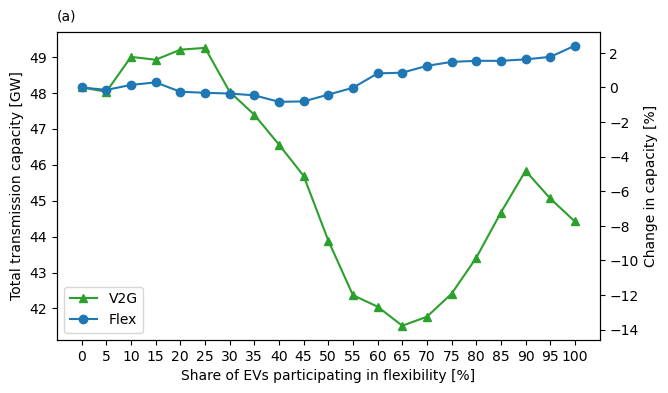

In [54]:
#trans_cap_tot['Flex'].loc[trans_cap_tot['Flex'] != 0].plot(figsize=(10,5), style='-o', legend=True)
trans_cap_tot['V2G'].plot(figsize=(7,4), color='tab:green', style='-^', legend=True)
trans_cap_tot['Flex'].plot(style='-o', legend=True, color='tab:blue')

plt.ylabel('Total transmission capacity [GW]')
# plt.grid()

(((trans_cap_tot['V2G'] - trans_cap_tot['V2G'][0])/trans_cap_tot['V2G'][0])*100).plot(secondary_y=True, linewidth=0)
(((trans_cap_tot['Flex'] - trans_cap_tot['Flex'][0])/trans_cap_tot['Flex'][0])*100).plot(secondary_y=True, linewidth=0, xlabel='Share of EVs participating in flexibility [%]')
plt.ylabel('Change in capacity [%]')

plt.xticks(trans_cap_tot.index.values)

plt.text(-5,3.85,'(a)')

# plt.savefig('trans.svg', transparent=True, bbox_inches="tight")

plt.show()

In [60]:
mode = 'V2G'
((trans_cap_tot[mode] - trans_cap_tot[mode][0])/trans_cap_tot[mode][0])*100

participation
0       0.000000
5      -0.249221
10      1.765317
15      1.599169
20      2.180685
25      2.284528
30     -0.249221
35     -1.578401
40     -3.302181
45     -5.109034
50     -8.847352
55    -12.004154
60    -12.668744
65    -13.769470
70    -13.250260
75    -11.921080
80     -9.844237
85     -7.227414
90     -4.818276
95     -6.417445
100    -7.746625
Name: V2G, dtype: float64

(0.0, 9.0)

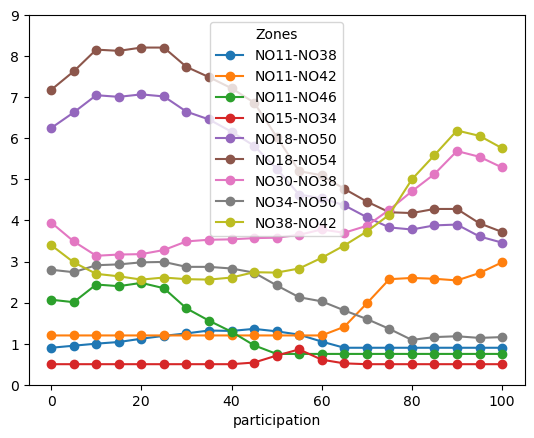

In [61]:
# only plot the transmission lines where the capacity change (and is not very small)
trans_cap_zone['V2G'][['NO11-NO38', 'NO11-NO42', 'NO11-NO46', 'NO15-NO34', 'NO18-NO50', 'NO18-NO54', 'NO30-NO38', 'NO34-NO50', 'NO38-NO42']].plot(style='-o')
plt.ylim(0,9)

## Transmission and generation capacity in one plot

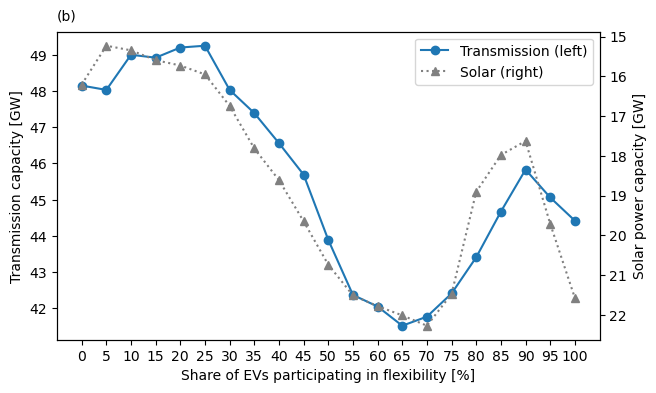

In [62]:
fig,ax1 = plt.subplots(figsize=(7,4))
ax2 = ax1.twinx()
a, = ax1.plot(trans_cap_tot['V2G'].index, trans_cap_tot['V2G'].values, linestyle='-', marker='o', color='tab:blue')
b, = ax2.plot(gen_V2G_on.Solar.index, gen_V2G_on.Solar.values, linestyle=':', marker='^', color='gray')
ax2.invert_yaxis()
plt.legend([a,b],['Transmission (left)','Solar (right)'])
#ax1.grid()

ax1.set_ylabel('Transmission capacity [GW]')
ax2.set_ylabel('Solar power capacity [GW]')
ax1.set_xlabel('Share of EVs participating in flexibility [%]')

plt.xticks(trans_cap_tot.index.values)

plt.text(-5,14.6,'(b)')

# plt.savefig('trans+solar.svg', transparent=True, bbox_inches="tight")

plt.show()

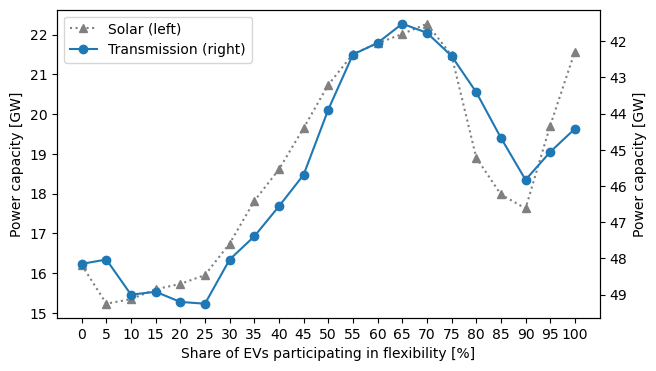

In [63]:
fig,ax1 = plt.subplots(figsize=(7,4))
ax2 = ax1.twinx()
a, = ax1.plot(gen_V2G_on.Solar.index, gen_V2G_on.Solar.values, linestyle=':', marker='^', color='gray')
b, = ax2.plot(trans_cap_tot['V2G'].index, trans_cap_tot['V2G'].values, linestyle='-', marker='o', color='tab:blue')
ax2.invert_yaxis()
plt.legend([a,b],['Solar (left)','Transmission (right)'])
#ax1.grid()

ax1.set_ylabel('Power capacity [GW]')
ax2.set_ylabel('Power capacity [GW]')
ax1.set_xlabel('Share of EVs participating in flexibility [%]')

plt.xticks(trans_cap_tot.index.values)

plt.show()

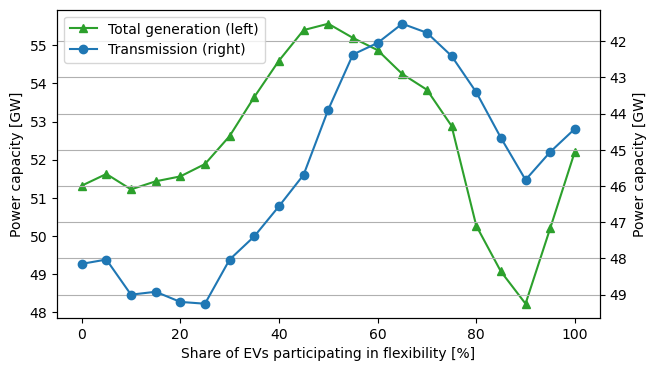

In [64]:
fig,ax1 = plt.subplots(figsize=(7,4))
ax2 = ax1.twinx()
a, = ax1.plot(gen_V2G_on.T.sum().index, gen_V2G_on.T.sum().values, linestyle='-', marker='^', color='tab:green')
b, = ax2.plot(trans_cap_tot['V2G'].index, trans_cap_tot['V2G'].values, linestyle='-', marker='o', color='tab:blue')
ax2.invert_yaxis()
plt.legend([a,b],['Total generation (left)','Transmission (right)'])

ax1.set_ylabel('Power capacity [GW]')
ax2.set_ylabel('Power capacity [GW]')
ax1.set_xlabel('Share of EVs participating in flexibility [%]')
plt.grid()

plt.show()

KeyError: 'ON'

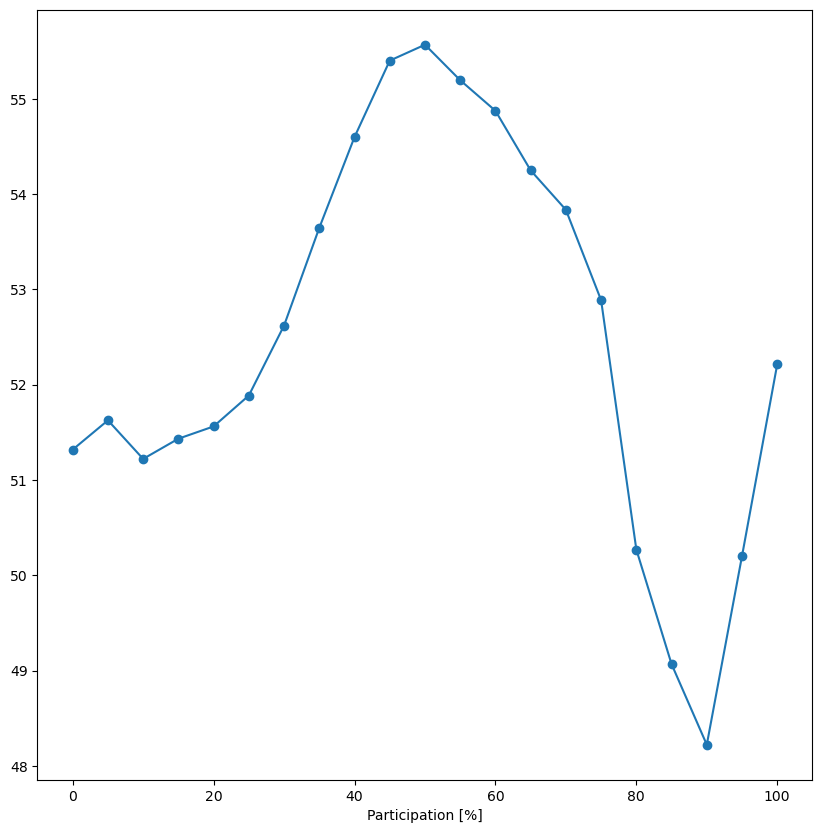

In [65]:
gen_V2G_on.T.sum().plot(style='-o', label='Generation', figsize=(10,10))
trans_cap_tot['ON'].plot(style='-o', label='Transmission')
# (gen_V2G_on.T.sum() + trans_cap_tot['ON']).plot(style='-o', label='Total')
plt.ylabel('Power capacity [GW]')
plt.xlabel('Share of EVs participating in flexibility [%]')
plt.grid()
plt.legend()
plt.show()

The plot below shows the gradient of the gradient. That is the change in the gradient of the transmission capacity. What appears is that the gradient decrease up to about 50% and after that point it starts increasing.

In [66]:
# plt.plot(trans_cap_tot['ON'].index.values, trans_cap_tot['ON'].values, marker='o')
# plt.plot(trans_cap_tot['ON'].index.values, np.gradient(trans_cap_tot['ON'].values, trans_cap_tot['ON'].index.values), marker='o')
plt.plot(trans_cap_tot['ON'].index.values, np.gradient(np.gradient(trans_cap_tot['ON'].values, trans_cap_tot['ON'].index.values), trans_cap_tot['ON'].index.values), marker='o')
plt.xticks(trans_cap_tot['ON'].index.values)
plt.grid()
plt.show()

KeyError: 'ON'

KeyError: 'ON'

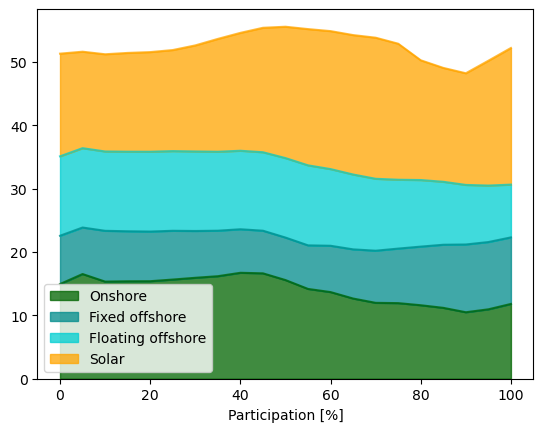

In [67]:
colours = {'Onshore':'darkgreen','Fixed offshore':'darkcyan', 'Floating offshore':'darkturquoise', 'Hydropower run-of-river':'cornflowerblue','Solar':'orange','Hydropower reservoir':'blue','Stationary batteries':'red','Import':'slategrey','Pumped hydro':'slateblue'}

gen_V2G_on.plot.area(stacked=True, color=colours, alpha=0.75) #.T.sum().plot(style='-o', label='Generation')
trans_cap_tot['ON'].plot(linestyle='-', linewidth=1, marker='.', markersize=10, label='Transmission', color='Black')
plt.xlim(0,100)
plt.legend()
plt.show()

In [68]:
(gen_V2G_on.T.sum() + trans_cap_tot['ON']).plot(style='-o', label='Total')
plt.ylabel('Power capacity [GW]')
plt.xlabel('Share of EVs participating in flexibility [%]')
plt.grid()
plt.legend()
plt.show()

KeyError: 'ON'

In [69]:
zone = 'NO30'
V2G = 'ON'

In [70]:
cap_z = makenice(sqlite_list, "cap_z").query("level_2 == 'level' and zone == '" + zone + "' and V2G == '" + V2G + "'").round(2)

store_z = makenice(sqlite_list, "storage_pcap_z").query("level_2 == 'level' and zone == '" + zone + "' and V2G == '" + V2G + "'").round(2)

100%|██████████| 42/42 [00:00<00:00, 153.37it/s]


KeyError: 'ON'

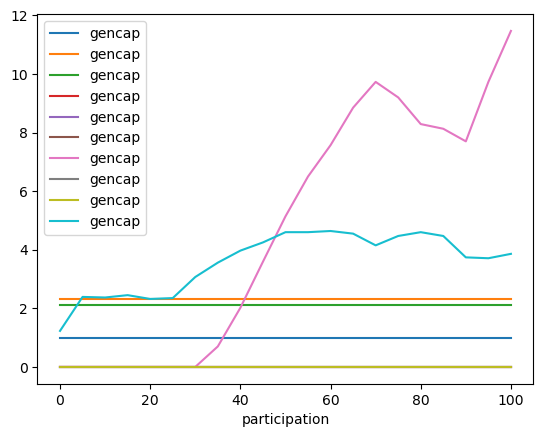

In [71]:
fig, ax = plt.subplots()

for i in cap_z.reset_index().technology.unique():
    f = cap_z.query("technology == '" + i + "'").reset_index().set_index('participation')
    f.index = f.index.astype('int')
    f.sort_index().plot(ax=ax)

trans_cap_zone[V2G].T[trans_cap_zone[V2G].columns.str.contains(zone)].T.plot(ax=ax)

s = store_z.query("technology == 'Li-ion-8'").reset_index().set_index('participation')
s.index = s.index.astype('int')
s.plot(ax=ax)

## Stationary battery storage

In [27]:
storage = makenice(sqlite_list, "storage_ecap")

100%|██████████| 42/42 [00:00<00:00, 170.67it/s]


In [28]:
battery = storage.query("technology == 'Li-ion-8' and level_1 == 'level' and V2G == 'OFF'").groupby(['participation']).sum().rename(columns={'storeecaptot':'Flex'})
battery['V2G'] = storage.query("technology == 'Li-ion-8' and level_1 == 'level' and V2G == 'ON'").groupby(['participation']).sum()

battery.index = battery.index.astype(int)

battery = battery.sort_values('participation')

battery.index.names = ['Participation [%]']

In [63]:
(((battery['Flex'] - battery['Flex'][0])/battery['Flex'][0])*100).round(1)

Participation [%]
0       0.0
5      -1.7
10     -3.0
15     -4.4
20     -5.2
25     -6.3
30     -7.3
35     -8.3
40     -8.8
45    -10.4
50    -12.3
55    -14.2
60    -16.5
65    -17.8
70    -19.9
75    -21.5
80    -23.2
85    -24.1
90    -25.6
95    -27.1
100   -29.0
Name: Flex, dtype: float64

In [65]:
(((battery['V2G'] - battery['V2G'][0])/battery['V2G'][0])*100).round(1)

Participation [%]
0        0.0
5      -19.5
10     -35.8
15     -46.2
20     -57.9
25     -68.5
30     -74.8
35     -83.1
40     -90.7
45     -97.7
50    -100.0
55    -100.0
60    -100.0
65    -100.0
70    -100.0
75    -100.0
80    -100.0
85    -100.0
90    -100.0
95    -100.0
100   -100.0
Name: V2G, dtype: float64

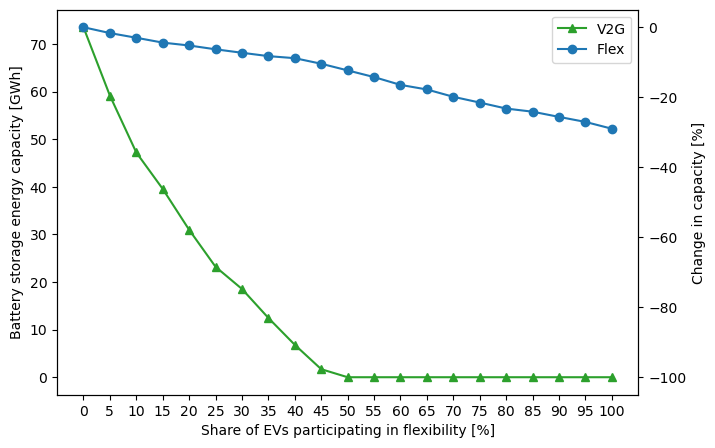

In [74]:
battery['V2G'].plot(figsize=(7.5,5), style='-^', color='tab:green', legend=True)
battery['Flex'].plot(figsize=(7.5,5), style='-o', color='tab:blue', legend=True)
plt.ylabel('Battery storage energy capacity [GWh]')
# plt.grid()

(((battery['Flex'] - battery['Flex'][0])/battery['Flex'][0]).round(4)*100).plot(secondary_y = True, linewidth = 0)
(((battery['V2G'] - battery['V2G'][0])/battery['V2G'][0]).round(4)*100).plot(secondary_y = True, linewidth = 0, xlabel='Share of EVs participating in flexibility [%]')

plt.ylabel('Change in capacity [%]')

plt.xticks(battery.index.values)

# plt.savefig('batteries.svg', transparent=True, bbox_inches="tight")

plt.show()

In [75]:
((battery['Flex'][0] - battery['Flex'][100]))/battery['Flex'][0]

np.float64(0.29000519832649924)

In [76]:
battery['Flex'][0]*(1-0.014500259916324964*20)

np.float64(52.20575077139821)

In [77]:
battery['Flex']

Participation [%]
0      73.529765
5      72.302608
10     71.316783
15     70.297297
20     69.692824
25     68.889857
30     68.162981
35     67.457953
40     67.025915
45     65.854814
50     64.459076
55     63.054867
60     61.413189
65     60.450763
70     58.911319
75     57.701036
80     56.443467
85     55.782542
90     54.690736
95     53.632590
100    52.205751
Name: Flex, dtype: float64

In [78]:
battery['Flex'][0] - 0.1918470303568675*20

np.float64(69.69282418599366)

In [79]:
a = (((battery['Flex'] - battery['Flex'][0])/battery['Flex'][0])*100).to_list()
b = []
for i in range(1,len(a)):
    b.append(a[i] - a[i-1])

In [80]:
np.mean(b)

np.float64(-1.4500259916324962)

In [81]:
a[-1]/20

-1.4500259916324962

In [82]:
battery['Flex']

Participation [%]
0      73.529765
5      72.302608
10     71.316783
15     70.297297
20     69.692824
25     68.889857
30     68.162981
35     67.457953
40     67.025915
45     65.854814
50     64.459076
55     63.054867
60     61.413189
65     60.450763
70     58.911319
75     57.701036
80     56.443467
85     55.782542
90     54.690736
95     53.632590
100    52.205751
Name: Flex, dtype: float64

In [83]:
battery['Flex'][0]*(1+(a[-1]/20)/100)**24

np.float64(51.78685229222729)

## Stationary battery storage + EVs

In [84]:
cars = pd.DataFrame({'NO03':324154,'NO11':283611,'NO15':172388,'NO18':151072,'NO30':822426,'NO34':263113,'NO38':266854,'NO42':187489,'NO46':351529,'NO50':278712,'NO54':146291},index=['Cars'])
# participation = pd.DataFrame({'0%':0.00,'5%':0.05,'10%':0.10,'15%':0.15,'20%':0.20,'25%':0.25,'30%':0.30,'35%':0.35,'40%':0.40,'45%':0.45,'50%':0.50,'55%':0.55,'60%':0.60,'65%':0.65,'70%':0.70,'75%':0.75,'80%':0.80,'85%':0.85,'90%':0.90,'95%':0.95,'100%':1.00},index=['Cars'])

participation = pd.DataFrame({0:0.00,5:0.05,10:0.10,15:0.15,20:0.20,25:0.25,30:0.30,35:0.35,40:0.40,45:0.45,50:0.50,55:0.55,60:0.60,65:0.65,70:0.70,75:0.75,80:0.80,85:0.85,90:0.90,95:0.95,100:1.00},index=['Cars'])

In [85]:
batteries = battery.copy()
batteries['EV battery capacity'] = (cars.T.dot(participation).sum()*0.000094)
batteries['V2G OFF (stationary + participating EVs)'] = batteries['V2G OFF'] + batteries['EV battery capacity']
batteries['V2G ON (stationary + participating EVs)'] = batteries['V2G ON'] + batteries['EV battery capacity']

KeyError: 'V2G OFF'

In [86]:
batteries[['EV battery capacity', 'V2G OFF (stationary + participating EVs)', 'V2G ON (stationary + participating EVs)']].plot(figsize=(7.5,5), style=['--','-o','-o'])
plt.ylabel('Battery storage energy capacity [stationary + participating EVs] [GWh]')
plt.xlabel('Share of EVs participating in flexibility [%]')
plt.grid()

KeyError: "['V2G OFF (stationary + participating EVs)', 'V2G ON (stationary + participating EVs)'] not in index"

## Stationary batteries + generation capacities

In [87]:
storage = makenice(sqlite_list, "storage_pcap")
battery = storage.query("technology == 'Li-ion-8' and level_1 == 'level' and V2G == 'OFF'").groupby(['participation']).sum().rename(columns={'storepcaptot':'Flex'})
battery['V2G'] = storage.query("technology == 'Li-ion-8' and level_1 == 'level' and V2G == 'ON'").groupby(['participation']).sum()

battery.index = battery.index.astype(int)

battery = battery.sort_values('participation')

battery.index.names = ['Participation [%]']

100%|██████████| 42/42 [00:00<00:00, 187.84it/s]


In [88]:
V2G_off = gen_V2G_off.copy()
V2G_off['Stationary batteries'] = battery.Flex

In [93]:
V2G_off.round(1)

,Onshore,Fixed offshore,Floating offshore,Solar,Stationary batteries
Participation [%],,,,,
0,14.9,7.6,12.5,16.2,9.2
5,14.9,7.7,12.5,16.2,9.0
10,14.9,7.6,12.4,16.5,8.9
15,15.0,7.6,12.4,16.6,8.8
20,15.1,7.5,12.3,16.7,8.7
25,15.2,7.5,12.3,16.9,8.6
30,15.3,7.4,12.2,17.1,8.5
35,15.3,7.3,12.2,17.4,8.4
40,15.2,7.3,12.1,17.9,8.4


In [89]:
V2G_on = gen_V2G_on.copy()
V2G_on['Stationary batteries'] = battery.V2G

In [94]:
V2G_on.round(1)

,Onshore,Fixed offshore,Floating offshore,Solar,Stationary batteries
Participation [%],,,,,
0,14.9,7.6,12.5,16.2,9.2
5,16.5,7.3,12.5,15.2,7.4
10,15.3,8.0,12.5,15.3,5.9
15,15.4,7.9,12.6,15.6,4.9
20,15.4,7.8,12.6,15.7,3.9
25,15.7,7.7,12.6,16.0,2.9
30,15.9,7.4,12.6,16.7,2.3
35,16.2,7.2,12.5,17.8,1.6
40,16.7,6.9,12.4,18.6,0.9


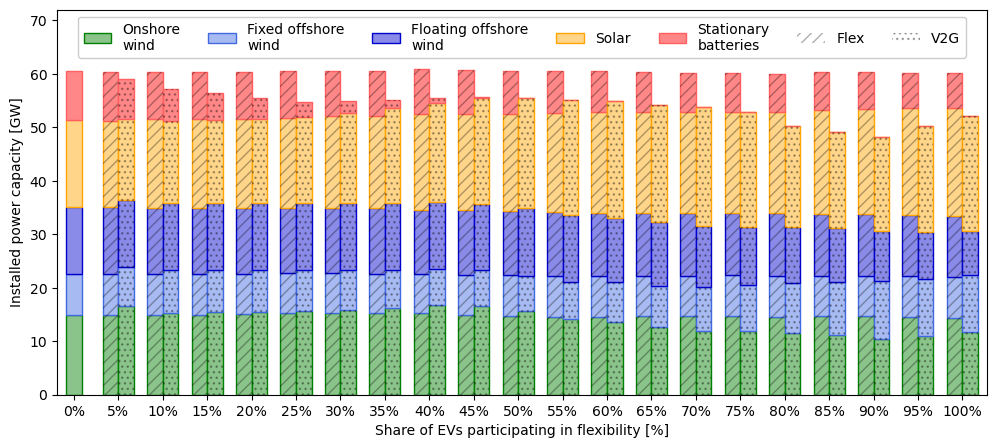

In [90]:
# colours = {'Onshore':'#00800075', 'Fixed offshore':'#4169e175', 'Floating offshore':'#0000cd75', 'Solar':'#ffa50075'}
colours = {'Onshore':'#8ac48a', 'Fixed offshore':'#a7baf1', 'Floating offshore':'#8a8ae8', 'Solar':'#ffd58a', 'Stationary batteries':'#ff8787'}
edgecolours = {'Onshore':'#008000', 'Fixed offshore':'#4169e1', 'Floating offshore':'#0000cd', 'Solar':'#ffa500', 'Stationary batteries':'#ff5f5f'}

xticks = (pd.Series(np.linspace(0, 100, 21, dtype=int)).astype(str) + '%').values

barwidth = 0.35
buffer = 0

fig, ax = plt.subplots(figsize = (12,5))

plt.bar(barwidth/2, V2G_off.loc[0,'Onshore'], width = barwidth, edgecolor=edgecolours.get('Onshore'), color=colours.get('Onshore'), zorder=2)
plt.bar(barwidth/2, V2G_off.loc[0,'Fixed offshore'], width = barwidth, bottom=V2G_off.loc[0,'Onshore'], edgecolor=edgecolours.get('Fixed offshore'), color=colours.get('Fixed offshore'), zorder=2)
plt.bar(barwidth/2, V2G_off.loc[0,'Floating offshore'], width = barwidth, bottom=V2G_off.loc[0,'Onshore']+V2G_off.loc[0,'Fixed offshore'], edgecolor=edgecolours.get('Floating offshore'), color=colours.get('Floating offshore'), zorder=2)
plt.bar(barwidth/2, V2G_off.loc[0,'Solar'], width = barwidth, bottom=V2G_off.loc[0,'Onshore']+V2G_off.loc[0,'Fixed offshore']+V2G_off.loc[0,'Floating offshore'], edgecolor=edgecolours.get('Solar'), color=colours.get('Solar'), zorder=2)
plt.bar(barwidth/2, V2G_off.loc[0,'Stationary batteries'], width = barwidth, bottom=V2G_off.loc[0,'Onshore']+V2G_off.loc[0,'Fixed offshore']+V2G_off.loc[0,'Floating offshore']+V2G_off.loc[0,'Solar'], edgecolor=edgecolours.get('Stationary batteries'), color=colours.get('Stationary batteries'), zorder=2)

plt.bar(np.arange(len(xticks))[1:]-buffer, V2G_off.loc[1:,'Onshore'], width = barwidth, edgecolor=edgecolours.get('Onshore'), color=colours.get('Onshore'), zorder=2)
plt.bar(np.arange(len(xticks))[1:]-buffer, V2G_off.loc[1:,'Fixed offshore'], width = barwidth, bottom=V2G_off.loc[1:,'Onshore'], edgecolor=edgecolours.get('Fixed offshore'), color=colours.get('Fixed offshore'), zorder=2)
plt.bar(np.arange(len(xticks))[1:]-buffer, V2G_off.loc[1:,'Floating offshore'], width = barwidth, bottom=V2G_off.loc[1:,'Onshore']+V2G_off.loc[1:,'Fixed offshore'], edgecolor=edgecolours.get('Floating offshore'), color=colours.get('Floating offshore'), zorder=2)
plt.bar(np.arange(len(xticks))[1:]-buffer, V2G_off.loc[1:,'Solar'], width = barwidth, bottom=V2G_off.loc[1:,'Onshore']+V2G_off.loc[1:,'Fixed offshore']+V2G_off.loc[1:,'Floating offshore'], edgecolor=edgecolours.get('Solar'), color=colours.get('Solar'), zorder=2)
plt.bar(np.arange(len(xticks))[1:]-buffer, V2G_off.loc[1:,'Stationary batteries'], width = barwidth, bottom=V2G_off.loc[1:,'Onshore']+V2G_off.loc[1:,'Fixed offshore']+V2G_off.loc[1:,'Floating offshore']+V2G_off.loc[1:,'Solar'], edgecolor=edgecolours.get('Stationary batteries'), color=colours.get('Stationary batteries'), zorder=2)

a = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, V2G_on.loc[1:,'Onshore'], width = barwidth, edgecolor=edgecolours.get('Onshore'), color=colours.get('Onshore'), zorder=2)
b = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, V2G_on.loc[1:,'Fixed offshore'], width = barwidth, bottom=V2G_on.loc[1:,'Onshore'], edgecolor=edgecolours.get('Fixed offshore'), color=colours.get('Fixed offshore'), zorder=2)
c = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, V2G_on.loc[1:,'Floating offshore'], width = barwidth, bottom=V2G_on.loc[1:,'Onshore']+V2G_on.loc[1:,'Fixed offshore'], edgecolor=edgecolours.get('Floating offshore'), color=colours.get('Floating offshore'), zorder=2)
d = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, V2G_on.loc[1:,'Solar'], width = barwidth, bottom=V2G_on.loc[1:,'Onshore']+V2G_on.loc[1:,'Fixed offshore']+V2G_on.loc[1:,'Floating offshore'], edgecolor=edgecolours.get('Solar'), color=colours.get('Solar'), zorder=2)
e = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, V2G_on.loc[1:,'Stationary batteries'], width = barwidth, bottom=V2G_on.loc[1:,'Onshore']+V2G_on.loc[1:,'Fixed offshore']+V2G_on.loc[1:,'Floating offshore']+V2G_on.loc[1:,'Solar'], edgecolor=edgecolours.get('Stationary batteries'), color=colours.get('Stationary batteries'), zorder=2)

f = plt.bar(np.arange(len(xticks))[1:]-buffer, V2G_off.loc[1:].T.sum(), width = barwidth, edgecolor='#00000050', color='#00000000', linewidth=0, zorder=2, hatch='///')
g = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, V2G_on.loc[1:].T.sum(), width = barwidth, edgecolor='#00000050', color='#00000000', linewidth=0, zorder=2, hatch='...')

plt.legend([a,b,c,d,e,f,g],['Onshore\nwind', 'Fixed offshore\nwind', 'Floating offshore\nwind', 'Solar', 'Stationary\nbatteries', 'Flex', 'V2G'], loc='upper center', ncols=7, framealpha=1)

# ax.axhline(V2G_off.loc[0,'Onshore'], linestyle='--', linewidth=1, color='black', zorder=1)
# ax.axhline(V2G_off.loc[0,'Onshore'] + V2G_off.loc[0,'Fixed offshore'], linestyle='--', linewidth=1, color='black', zorder=1)
# ax.axhline(V2G_off.loc[0,'Onshore'] + V2G_off.loc[0,'Fixed offshore'] + V2G_off.loc[0,'Floating offshore'], linestyle='--', linewidth=1, color='black', zorder=1)
# ax.axhline(V2G_off.loc[0,'Onshore'] + V2G_off.loc[0,'Fixed offshore'] + V2G_off.loc[0,'Floating offshore'] + V2G_off.loc[0,'Solar'], linestyle='--', linewidth=1, color='black', zorder=1)

# plt.grid(axis='y')

plt.xticks(np.arange(len(xticks)) + barwidth/2, xticks)

plt.ylim(0,72)

plt.xlabel('Share of EVs participating in flexibility [%]')
plt.ylabel('Installed power capacity [GW]')

ax.margins(x=0.01)

# plt.savefig('cap.svg', transparent=True, bbox_inches="tight")

plt.show()

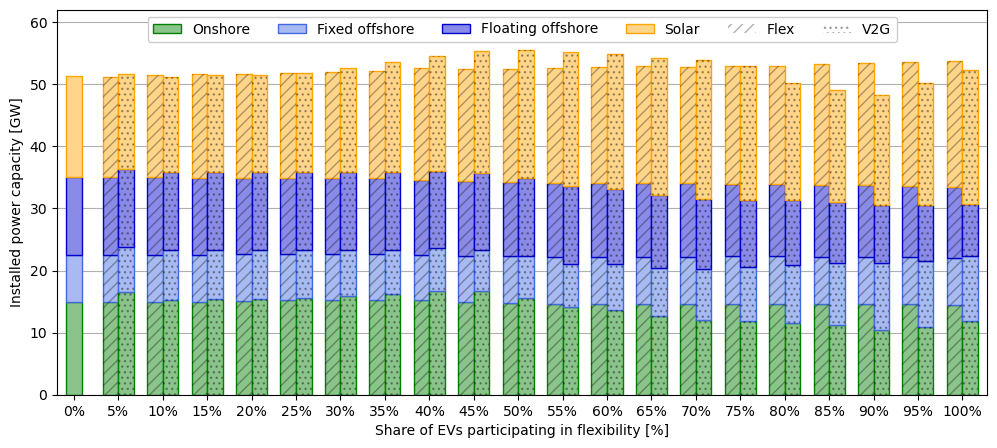

In [91]:
# colours = {'Onshore':'#00800075', 'Fixed offshore':'#4169e175', 'Floating offshore':'#0000cd75', 'Solar':'#ffa50075'}
colours = {'Onshore':'#8ac48a', 'Fixed offshore':'#a7baf1', 'Floating offshore':'#8a8ae8', 'Solar':'#ffd58a'}
edgecolours = {'Onshore':'#008000', 'Fixed offshore':'#4169e1', 'Floating offshore':'#0000cd', 'Solar':'#ffa500'}

xticks = (pd.Series(np.linspace(0, 100, 21, dtype=int)).astype(str) + '%').values

barwidth = 0.35
buffer = 0

fig, ax = plt.subplots(figsize = (12,5))

plt.bar(barwidth/2, gen_V2G_off.loc[0,'Onshore'], width = barwidth, edgecolor=edgecolours.get('Onshore'), color=colours.get('Onshore'), zorder=2)
plt.bar(barwidth/2, gen_V2G_off.loc[0,'Fixed offshore'], width = barwidth, bottom=gen_V2G_off.loc[0,'Onshore'], edgecolor=edgecolours.get('Fixed offshore'), color=colours.get('Fixed offshore'), zorder=2)
plt.bar(barwidth/2, gen_V2G_off.loc[0,'Floating offshore'], width = barwidth, bottom=gen_V2G_off.loc[0,'Onshore']+gen_V2G_off.loc[0,'Fixed offshore'], edgecolor=edgecolours.get('Floating offshore'), color=colours.get('Floating offshore'), zorder=2)
plt.bar(barwidth/2, gen_V2G_off.loc[0,'Solar'], width = barwidth, bottom=gen_V2G_off.loc[0,'Onshore']+gen_V2G_off.loc[0,'Fixed offshore']+gen_V2G_off.loc[0,'Floating offshore'], edgecolor=edgecolours.get('Solar'), color=colours.get('Solar'), zorder=2)

plt.bar(np.arange(len(xticks))[1:]-buffer, gen_V2G_off.loc[1:,'Onshore'], width = barwidth, edgecolor=edgecolours.get('Onshore'), color=colours.get('Onshore'), zorder=2)
plt.bar(np.arange(len(xticks))[1:]-buffer, gen_V2G_off.loc[1:,'Fixed offshore'], width = barwidth, bottom=gen_V2G_off.loc[1:,'Onshore'], edgecolor=edgecolours.get('Fixed offshore'), color=colours.get('Fixed offshore'), zorder=2)
plt.bar(np.arange(len(xticks))[1:]-buffer, gen_V2G_off.loc[1:,'Floating offshore'], width = barwidth, bottom=gen_V2G_off.loc[1:,'Onshore']+gen_V2G_off.loc[1:,'Fixed offshore'], edgecolor=edgecolours.get('Floating offshore'), color=colours.get('Floating offshore'), zorder=2)
plt.bar(np.arange(len(xticks))[1:]-buffer, gen_V2G_off.loc[1:,'Solar'], width = barwidth, bottom=gen_V2G_off.loc[1:,'Onshore']+gen_V2G_off.loc[1:,'Fixed offshore']+gen_V2G_off.loc[1:,'Floating offshore'], edgecolor=edgecolours.get('Solar'), color=colours.get('Solar'), zorder=2)

a = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, gen_V2G_on.loc[1:,'Onshore'], width = barwidth, edgecolor=edgecolours.get('Onshore'), color=colours.get('Onshore'), zorder=2)
b = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, gen_V2G_on.loc[1:,'Fixed offshore'], width = barwidth, bottom=gen_V2G_on.loc[1:,'Onshore'], edgecolor=edgecolours.get('Fixed offshore'), color=colours.get('Fixed offshore'), zorder=2)
c = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, gen_V2G_on.loc[1:,'Floating offshore'], width = barwidth, bottom=gen_V2G_on.loc[1:,'Onshore']+gen_V2G_on.loc[1:,'Fixed offshore'], edgecolor=edgecolours.get('Floating offshore'), color=colours.get('Floating offshore'), zorder=2)
d = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, gen_V2G_on.loc[1:,'Solar'], width = barwidth, bottom=gen_V2G_on.loc[1:,'Onshore']+gen_V2G_on.loc[1:,'Fixed offshore']+gen_V2G_on.loc[1:,'Floating offshore'], edgecolor=edgecolours.get('Solar'), color=colours.get('Solar'), zorder=2)

e = plt.bar(np.arange(len(xticks))[1:]-buffer, gen_V2G_off.loc[1:].T.sum(), width = barwidth, edgecolor='#00000050', color='#00000000', linewidth=0, zorder=2, hatch='///')
f = plt.bar(np.arange(len(xticks))[1:]+buffer+barwidth, gen_V2G_on.loc[1:].T.sum(), width = barwidth, edgecolor='#00000050', color='#00000000', linewidth=0, zorder=2, hatch='...')

plt.legend([a,b,c,d,e,f],['Onshore', 'Fixed offshore', 'Floating offshore', 'Solar', 'Flex', 'V2G'], loc='upper center', ncols=6, framealpha=1)

# ax.axhline(gen_V2G_off.loc[0,'Onshore'], linestyle='--', linewidth=1, color='black', zorder=1)
# ax.axhline(gen_V2G_off.loc[0,'Onshore'] + gen_V2G_off.loc[0,'Fixed offshore'], linestyle='--', linewidth=1, color='black', zorder=1)
# ax.axhline(gen_V2G_off.loc[0,'Onshore'] + gen_V2G_off.loc[0,'Fixed offshore'] + gen_V2G_off.loc[0,'Floating offshore'], linestyle='--', linewidth=1, color='black', zorder=1)
# ax.axhline(gen_V2G_off.loc[0,'Onshore'] + gen_V2G_off.loc[0,'Fixed offshore'] + gen_V2G_off.loc[0,'Floating offshore'] + gen_V2G_off.loc[0,'Solar'], linestyle='--', linewidth=1, color='black', zorder=1)

plt.grid(axis='y')

plt.xticks(np.arange(len(xticks)) + barwidth/2, xticks)

plt.ylim(0,62)

plt.xlabel('Share of EVs participating in flexibility [%]')
plt.ylabel('Installed power capacity [GW]')

ax.margins(x=0.01)
# plt.savefig('cap.jpg', dpi=600, bbox_inches="tight")
plt.show()

### Demand

In [110]:
con = connect("C:/Users/Tobias/OneDrive - Universitetet i Oslo/Documents/Projects/NUANCE/NUANCE results/NUANCE-results-050824/models/2010/region_0_off/results.db")

base_demand = pd.read_sql('SELECT * from demand', con) #.groupby('h', sort=False).sum(numeric_only=True)

#    elif technology in ['Pumped hydro charging','Stationary batteries charging']:
#        return pd.read_sql('SELECT * from var_store', con, index_col='s').loc[tech_dict[technology]].drop(columns=['lo','up','marginal']).groupby('h', sort=False).sum(numeric_only=True).set_index(time)
#
#    elif technology == 'Flexible EV charging':
#        return pd.read_sql('SELECT * from var_ev_charge',con).drop(columns=['lo','up','marginal']).groupby('h', sort=False).sum(numeric_only=True).set_index(time)
#    
#    elif technology == 'Vehicle to grid':
#        return pd.read_sql('SELECT * from var_ev_discharge', con).drop(columns=['lo','up','marginal']).groupby('h', sort=False).sum(numeric_only=True).set_index(time)
#
#    elif technology == 'Uncontrolled EV charging':
#        ev_charging = pd.read_sql('SELECT * from par_ev_charging', con).set_index(time).drop(columns=['h'])
#        vehicles = pd.read_sql('SELECT * from par_vehicles', con).value.sum()
#        charge_eff = 0.9149
#        return (ev_charging*vehicles)/charge_eff

con.close()

<Axes: xlabel='z'>

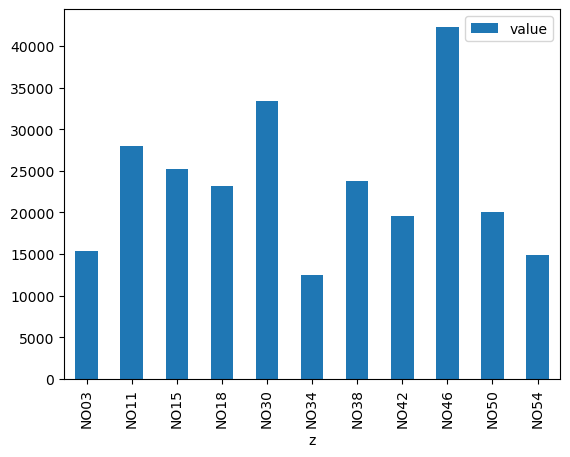

In [111]:
base_demand.drop(columns='h').groupby('z').sum().plot.bar()

In [112]:
demand = pd.DataFrame()
for i in ['Base demand','Pumped hydro charging','Stationary batteries charging','Uncontrolled EV charging']:
    demand[i] = read_results(technology=i, results_path="C:/Users/Tobias/OneDrive - Universitetet i Oslo/Documents/Projects/NUANCE/NUANCE results/NUANCE-results-050824/models/2010/region_0_off/results.db")

NameError: name 'read_results' is not defined

# Demand and supply balance

In [7]:
time = pd.date_range('2050', '2050-12-31-23', freq='h')

day = '2050-06-15'
# day = '2050-12-21'

In [8]:
tech_dict = {
        'Onshore wind':'Windonshore',
        'Fixed offshore wind':'Windoffshore',
        'Floating offshore wind':'Windoffshorefloating',
        'Hydropower run-of-river':'HydroRoR',
        'Hydropower reservoir':'HydroRes',
        'Solar PV':'Solar',
        'Import':'Import',
        'Pumped hydro':'PumpedHydro',
        'Stationary batteries':'Li-ion-8',
        'Vehicle to grid':0,
        'Base demand':0,
        'Pumped hydro charging':'PumpedHydro',
        'Stationary batteries charging':'Li-ion-8',
        'Flexible EV charging':0,
        'Uncontrolled EV charging':0,
        'Transmission losses':0,
        'Vehicle to grid':0
        }

In [9]:
def read_results(technology, results_path):

    con = connect(results_path)

    if technology in ['Onshore wind','Fixed offshore wind','Floating offshore wind','Hydropower run-of-river','Hydropower reservoir','Solar PV','Import']:
        return pd.read_sql('SELECT * from var_gen', con, index_col='g').loc[tech_dict[technology]].drop(columns=['lo','up','marginal']).groupby('h', sort=False).sum(numeric_only=True).set_index(time)
        
    elif technology in ['Pumped hydro', 'Stationary batteries']:
        return pd.read_sql('SELECT * from var_store_gen', con, index_col='s').loc[tech_dict[technology]].drop(columns=['lo','up','marginal']).groupby('h', sort=False).sum(numeric_only=True).set_index(time)

    elif technology == 'Vehicle to grid':
        return pd.read_sql('SELECT * from var_ev_discharge', con).drop(columns=['lo','up','marginal']).groupby('h', sort=False).sum(numeric_only=True).set_index(time)
    
    elif technology == 'Base demand':
        return pd.read_sql('SELECT * from demand', con).groupby('h', sort=False).sum(numeric_only=True).set_index(time)

    elif technology in ['Pumped hydro charging','Stationary batteries charging']:
        return pd.read_sql('SELECT * from var_store', con, index_col='s').loc[tech_dict[technology]].drop(columns=['lo','up','marginal']).groupby('h', sort=False).sum(numeric_only=True).set_index(time)

    elif technology == 'Flexible EV charging':
        return pd.read_sql('SELECT * from var_ev_charge',con).drop(columns=['lo','up','marginal']).groupby('h', sort=False).sum(numeric_only=True).set_index(time)
    
    elif technology == 'Vehicle to grid':
        return pd.read_sql('SELECT * from var_ev_discharge', con).drop(columns=['lo','up','marginal']).groupby('h', sort=False).sum(numeric_only=True).set_index(time)

    elif technology == 'Uncontrolled EV charging':
        ev_charging = pd.read_sql('SELECT * from par_ev_charging', con).set_index(time).drop(columns=['h'])
        vehicles = pd.read_sql('SELECT * from par_vehicles', con).value.sum()
        charge_eff = 0.9149
        return (ev_charging*vehicles)/charge_eff
    
    elif technology == 'Transmission losses':
        transflow = pd.read_sql('SELECT * from var_trans_flow', con, index_col=['z','z_alias']).drop(columns=['lo','up','marginal','trans']).astype({'h':int})
        transdist = pd.read_sql('SELECT * from trans_links_dist_bidir', con, index_col=['z','z_alias']).drop(columns=['trans'])
        trans_eff = 0.007
        return (pd.DataFrame(transflow.pivot(columns='h').T.mul(transdist.value).T.melt(ignore_index=False).reset_index().set_index(['h', 'z', 'z_alias'])['value'])*trans_eff).groupby('h').sum().set_index(time).value



    else:
        print(technology + 'is an unknown technology')

    con.close()


In [10]:
colours = {'Onshore wind':'darkgreen',
           'Fixed offshore wind':'darkcyan',
           'Floating offshore wind':'darkturquoise',
           'Hydropower run-of-river':'cornflowerblue',
           'Solar PV':'orange',
           'Hydropower reservoir':'blue',
           'Stationary batteries':'red',
           'Vehicle to grid':'crimson',
           'Import':'slategrey',
           'Pumped hydro':'slateblue'}

linewidth = 2
figsize = (7,4)

#### Base

In [11]:
gen = pd.DataFrame()
for i in ['Onshore wind','Fixed offshore wind','Floating offshore wind','Hydropower run-of-river','Hydropower reservoir','Solar PV','Pumped hydro','Stationary batteries']:
    gen[i] = read_results(technology=i, results_path='C:/Users/Tobias/OneDrive - Universitetet i Oslo/Documents/Projects/NUANCE/NUANCE results/NUANCE-results-050824/models/2010/region_0_off/results.db')

In [28]:
gen

,Onshore wind,Fixed offshore wind,Floating offshore wind,Hydropower run-of-river,Hydropower reservoir,Solar PV,Pumped hydro,Stationary batteries
2050-01-01 00:00:00,2.884891,0.202160,10.754690,4.152352,15.543257,0.0,2.077846e-09,7.685038e-07
2050-01-01 01:00:00,3.303916,0.125130,10.545290,4.152352,14.731539,0.0,2.077839e-09,7.303339e-07
2050-01-01 02:00:00,3.568596,0.121559,10.189722,4.152352,14.385941,0.0,2.072954e-09,6.968953e-07
2050-01-01 03:00:00,3.819400,0.182328,10.232219,4.152352,13.821491,0.0,2.072950e-09,6.687112e-07
2050-01-01 04:00:00,4.035956,0.161975,10.463382,4.142200,13.688025,0.0,2.072950e-09,6.440001e-07
...,...,...,...,...,...,...,...,...
2050-12-31 19:00:00,7.076112,7.285136,10.570140,3.799956,6.248165,0.0,2.057652e-09,1.102825e-06
2050-12-31 20:00:00,7.106902,7.438420,10.643224,3.799956,5.792991,0.0,2.057650e-09,1.000016e-06
2050-12-31 21:00:00,7.909413,7.558522,10.716308,3.799956,4.243066,0.0,2.057642e-09,9.220177e-07
2050-12-31 22:00:00,9.094751,7.594719,10.643224,3.799956,3.500544,0.0,2.055044e-09,1.725178e-07


In [29]:
demand = pd.DataFrame()
for i in ['Base demand','Pumped hydro charging','Stationary batteries charging','Uncontrolled EV charging','Transmission losses']:
    demand[i] = read_results(technology=i, results_path='C:/Users/Tobias/OneDrive - Universitetet i Oslo/Documents/Projects/NUANCE/NUANCE results/NUANCE-results-050824/models/2010/region_0_off/results.db')

In [32]:
demand['Stationary batteries charging']

2050-01-01 00:00:00    7.867469e-07
2050-01-01 01:00:00    7.891483e-07
2050-01-01 02:00:00    8.325057e-07
2050-01-01 03:00:00    8.350103e-07
2050-01-01 04:00:00    8.375466e-07
                           ...     
2050-12-31 19:00:00    4.952855e-01
2050-12-31 20:00:00    5.628756e-01
2050-12-31 21:00:00    7.558363e-01
2050-12-31 22:00:00    1.920677e+00
2050-12-31 23:00:00    2.177542e+00
Freq: h, Name: Stationary batteries charging, Length: 8760, dtype: float64

In [ ]:
colours = {'Onshore wind':,
           'Fixed offshore wind':,
           'Floating offshore wind':,
           'Solar PV':,

linewidth = 2
figsize = (7,4)

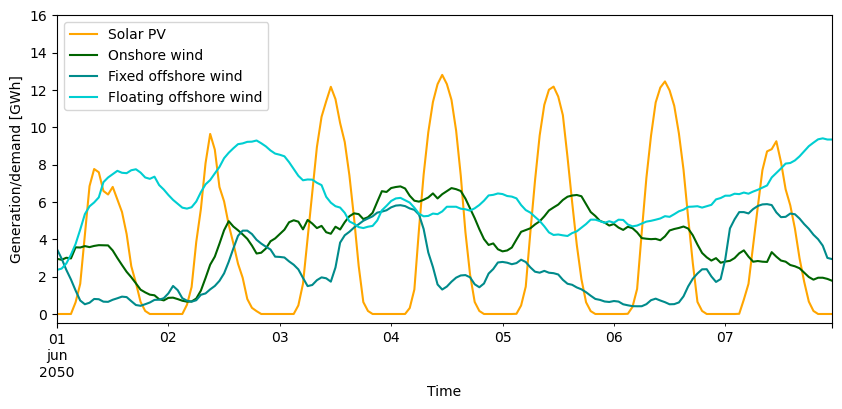

In [100]:
date_range = ['2050-06-01', '2050-06-07']

# (gen['Onshore wind'] +  gen['Fixed offshore wind'] + gen['Floating offshore wind']).loc['2050-06-07':'2050-06-08'].plot()

gen['Solar PV'].loc[date_range[0]:date_range[1]].plot(legend=True, color='orange', figsize=(10,4))

gen['Onshore wind'].loc[date_range[0]:date_range[1]].plot(legend=True, color='darkgreen')

gen['Fixed offshore wind'].loc[date_range[0]:date_range[1]].plot(legend=True, color='darkcyan')

gen['Floating offshore wind'].loc[date_range[0]:date_range[1]].plot(legend=True, color='darkturquoise')

# gen['Stationary batteries'].loc[date_range[0]:date_range[1]].plot(legend=True)

# demand['Stationary batteries charging'].loc[date_range[0]:date_range[1]].plot(legend=True)

plt.xlabel('Time')
plt.ylabel('Generation/demand [GWh]')

plt.ylim(-0.5,16)

plt.show()

<Axes: >

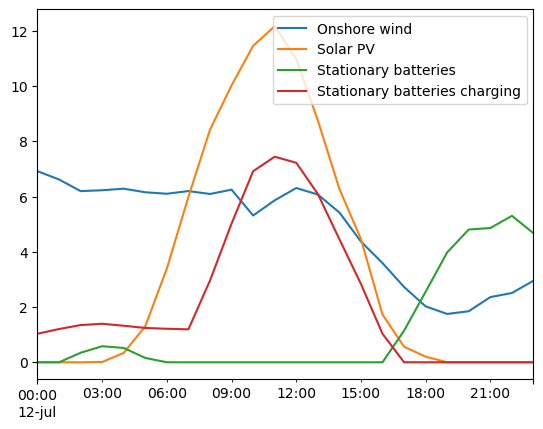

In [77]:
date_range = ['2050-07-12', '2050-07-12']

# (gen['Onshore wind'] +  gen['Fixed offshore wind'] + gen['Floating offshore wind']).loc['2050-06-07':'2050-06-08'].plot()

gen['Onshore wind'].loc[date_range[0]:date_range[1]].plot(legend=True)

gen['Solar PV'].loc[date_range[0]:date_range[1]].plot(legend=True)

gen['Stationary batteries'].loc[date_range[0]:date_range[1]].plot(legend=True)

demand['Stationary batteries charging'].loc[date_range[0]:date_range[1]].plot(legend=True)

<Axes: >

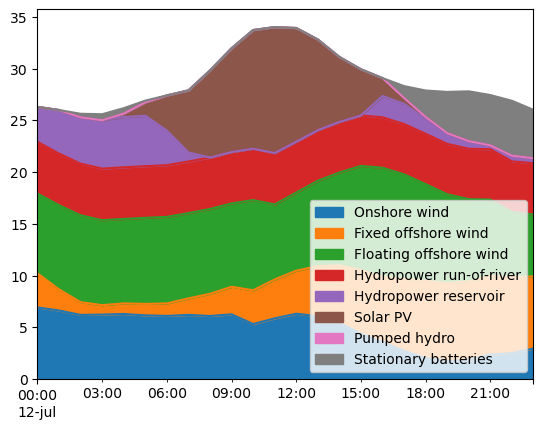

In [86]:
gen.loc[date_range[0]:date_range[1]].plot.area()

<Axes: >

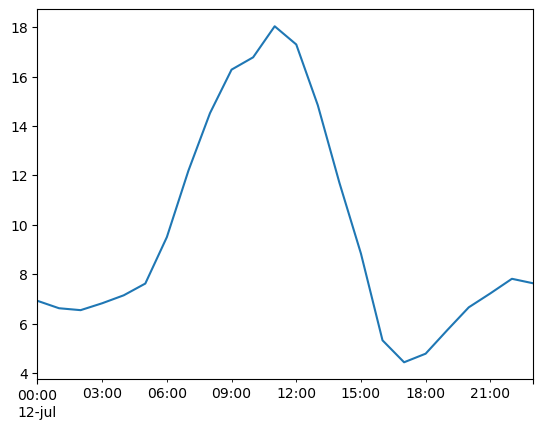

In [82]:
(gen['Onshore wind'] + gen['Solar PV'] + gen['Stationary batteries']).loc[date_range[0]:date_range[1]].plot()

<Axes: >

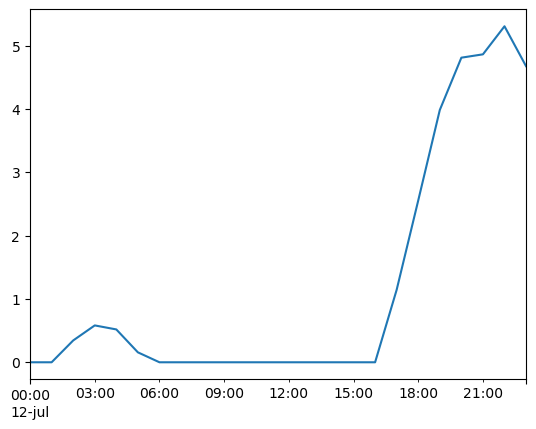

In [76]:
gen['Stationary batteries'].loc['2050-07-12'].plot()

<Axes: >

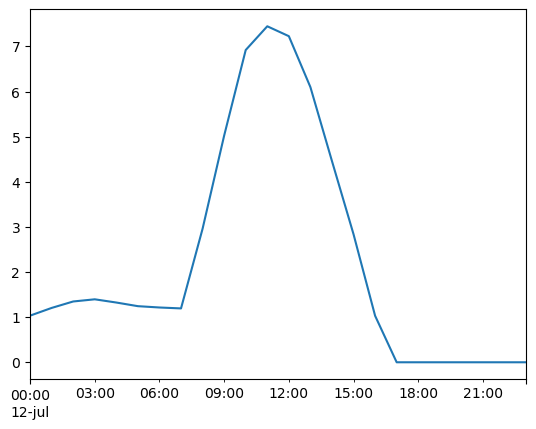

In [74]:
demand['Stationary batteries charging'].loc['2050-07-12'].plot()

In [32]:
LIB = pd.DataFrame()
LIB['charge'] = demand['Stationary batteries charging'].round(3)
LIB['discharge'] = gen['Stationary batteries'].round(3)

In [33]:
LIB.query("charge > 0 and discharge > 0")

,charge,discharge
2050-01-05 11:00:00,0.478,0.182
2050-01-06 00:00:00,0.365,0.439
2050-01-06 01:00:00,0.642,0.389
2050-01-06 02:00:00,0.955,0.366
2050-01-06 03:00:00,1.107,0.369
...,...,...
2050-12-25 21:00:00,0.057,2.402
2050-12-25 22:00:00,0.553,1.766
2050-12-25 23:00:00,0.849,1.185
2050-12-26 00:00:00,0.972,1.035


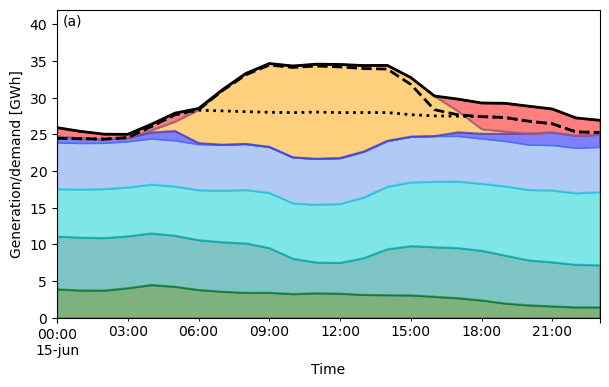

In [214]:
day_gen = gen.loc[day]
day_demand = demand.loc[day]

# plt.rcParams.update({'font.size': 18})
fig, ax=plt.subplots(figsize=figsize)
day_gen.plot.area(stacked=True, ax=ax, color=colours, alpha=0.5)
pd.DataFrame((day_demand['Base demand'] + day_demand['Transmission losses'])).rename(columns={0:'Demand'}).plot(ax=ax, linewidth=linewidth, color='Black', linestyle=':')
pd.DataFrame((day_demand['Base demand'] + day_demand['Transmission losses'] + day_demand['Pumped hydro charging'] + day_demand['Stationary batteries charging'])).rename(columns={0:'Demand + storage'}).plot(ax=ax, linewidth=linewidth, color='Black', linestyle='--')
pd.DataFrame((day_demand['Base demand'] + day_demand['Transmission losses'] + day_demand['Pumped hydro charging'] + day_demand['Stationary batteries charging'] + day_demand['Uncontrolled EV charging'])).rename(columns={0:'Demand + storage + EV'}).plot(ax=ax, linewidth=linewidth, color='Black')
plt.xlabel('Time')
plt.ylabel('Generation/demand [GWh]')
# plt.legend(bbox_to_anchor=(1,0.705))
# plt.title('Generation and demand ' + day)
ax.get_legend().remove()
plt.ylim(0,42)
plt.text(0.01,0.95,'(a)', transform=ax.transAxes)

# plt.savefig('winter_noflex.svg', transparent=True, bbox_inches="tight") #, dpi=1800)

plt.show()

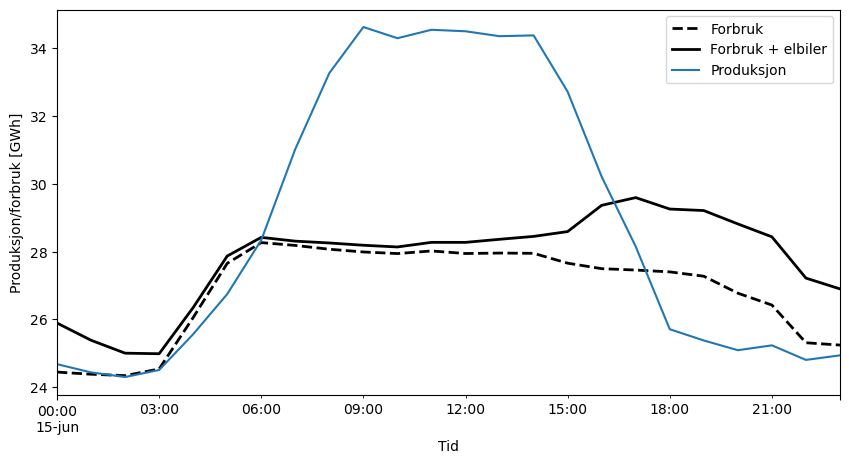

In [223]:
fig, ax=plt.subplots(figsize=(7.5*(493/366),5))
pd.DataFrame((day_demand['Base demand'] + day_demand['Transmission losses'])).rename(columns={0:'Forbruk'}).plot(ax=ax, linewidth=linewidth, color='Black', linestyle='--')
pd.DataFrame((day_demand['Base demand'] + day_demand['Transmission losses'] + day_demand['Uncontrolled EV charging'])).rename(columns={0:'Forbruk + elbiler'}).plot(ax=ax, linewidth=linewidth, color='Black')


#day_gen_new = pd.DataFrame()
#day_gen_new['Vannkraft'] = day_gen['Hydropower run-of-river'] # + day_gen['Hydropower reservoir'] + day_gen['Pumped hydro'] # + day_gen['Stationary batteries']
#day_gen_new['Vindkraft'] = day_gen['Onshore wind'] + day_gen['Fixed offshore wind'] + day_gen['Floating offshore wind']
#day_gen_new['Solkraft'] = day_gen['Solar PV']
#day_gen_new.plot(stacked=True, color={'Vindkraft':'darkgreen','Solkraft':'orange','Vannkraft':'blue'}, alpha=0.5, ax=ax)
day_gen.drop(columns=['Stationary batteries']).sum(axis=1).rename('Produksjon').plot(legend=True, ax=ax)

plt.xlabel('Tid')
plt.ylabel('Produksjon/forbruk [GWh]')
plt.show()

#### Flexible charging

In [121]:
gen = pd.DataFrame()
for i in ['Onshore wind','Fixed offshore wind','Floating offshore wind','Hydropower run-of-river','Hydropower reservoir','Solar PV','Pumped hydro','Stationary batteries']:
    gen[i] = read_results(technology=i, results_path='C:/Users/Tobias/OneDrive - Universitetet i Oslo/Documents/Projects/NUANCE/NUANCE results/NUANCE-results-050824/models/2010/region_100_off/results.db')

In [122]:
demand = pd.DataFrame()
for i in ['Base demand','Pumped hydro charging','Stationary batteries charging','Flexible EV charging','Transmission losses']:
    demand[i] = read_results(technology=i, results_path='C:/Users/Tobias/OneDrive - Universitetet i Oslo/Documents/Projects/NUANCE/NUANCE results/NUANCE-results-050824/models/2010/region_100_off/results.db')

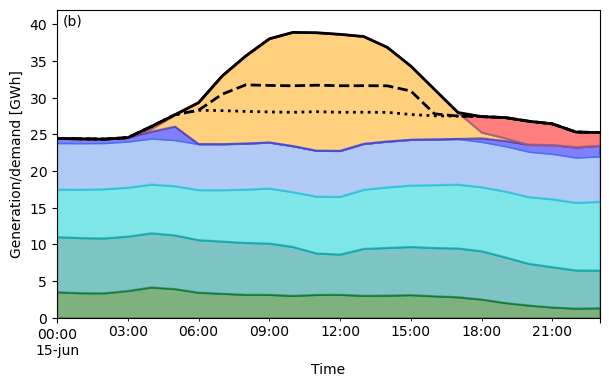

In [123]:
day_gen = gen.loc[day]
day_demand = demand.loc[day]

fig, ax=plt.subplots(figsize=figsize)
day_gen.plot.area(stacked=True, ax=ax, color=colours, alpha=0.5)
pd.DataFrame(day_demand['Base demand'] + day_demand['Transmission losses']).rename(columns={0:'Demand'}).plot(ax=ax, linewidth=linewidth, color='Black', linestyle=':')
pd.DataFrame(day_demand['Base demand'] + day_demand['Transmission losses'] + day_demand['Pumped hydro charging'] + day_demand['Stationary batteries charging']).rename(columns={0:'Demand + storage'}).plot(ax=ax, linewidth=linewidth, color='Black', linestyle='--')
pd.DataFrame(day_demand['Base demand'] + day_demand['Transmission losses'] + day_demand['Pumped hydro charging'] + day_demand['Stationary batteries charging'] + day_demand['Flexible EV charging']).rename(columns={0:'Demand + storage + EV'}).plot(ax=ax, linewidth=linewidth, color='Black')
plt.xlabel('Time')
plt.ylabel('Generation/demand [GWh]')
# plt.legend(bbox_to_anchor=(1,0.705))
# plt.title('Generation and demand ' + day)
ax.get_legend().remove()
plt.ylim(0,42)
plt.text(0.01,0.95,'(b)', transform=ax.transAxes)

# plt.savefig('winter_100flex.svg', transparent=True, bbox_inches="tight")

plt.show()
# fig.savefig('flex.jpg', dpi=600, bbox_inches="tight")

#### V2G

In [224]:
gen = pd.DataFrame()
for i in ['Onshore wind','Fixed offshore wind','Floating offshore wind','Hydropower run-of-river','Hydropower reservoir','Solar PV','Pumped hydro','Stationary batteries','Vehicle to grid']:
    gen[i] = read_results(technology=i, results_path='C:/Users/Tobias/OneDrive - Universitetet i Oslo/Documents/Projects/NUANCE/NUANCE results/NUANCE-results-050824/models/2010/region_100_on/results.db')

In [225]:
demand = pd.DataFrame()
for i in ['Base demand','Pumped hydro charging','Flexible EV charging','Transmission losses']:
    demand[i] = read_results(technology=i, results_path='C:/Users/Tobias/OneDrive - Universitetet i Oslo/Documents/Projects/NUANCE/NUANCE results/NUANCE-results-050824/models/2010/region_100_on/results.db')

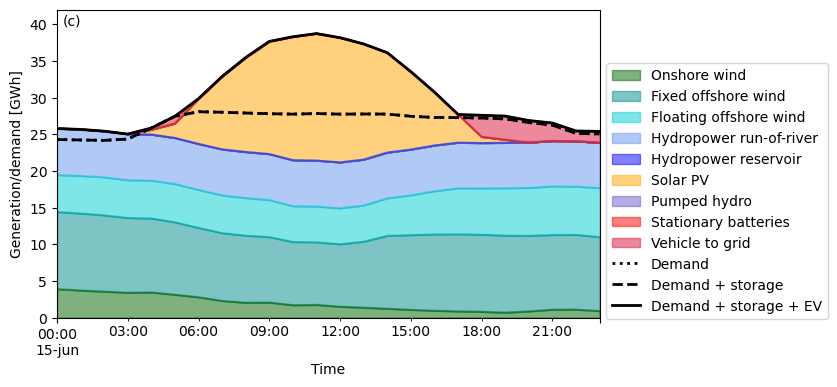

In [226]:
day_gen = gen.loc[day]
day_demand = demand.loc[day]

fig, ax=plt.subplots(figsize=figsize)
day_gen.plot.area(stacked=True, ax=ax, color=colours, alpha=0.5)
pd.DataFrame(day_demand['Base demand'] + day_demand['Transmission losses']).rename(columns={0:'Demand'}).plot(ax=ax, linewidth=2, color='Black', linestyle=':')
pd.DataFrame(day_demand['Base demand'] + day_demand['Transmission losses'] + day_demand['Pumped hydro charging']).rename(columns={0:'Demand + storage'}).plot(ax=ax, linewidth=2, color='Black', linestyle='--')
pd.DataFrame(day_demand['Base demand'] + day_demand['Transmission losses'] + day_demand['Pumped hydro charging'] + day_demand['Flexible EV charging']).rename(columns={0:'Demand + storage + EV'}).plot(ax=ax, linewidth=2, color='Black')
plt.xlabel('Time')
plt.ylabel('Generation/demand [GWh]')
plt.legend(bbox_to_anchor=(1,0.848))
# plt.title('Generation and demand ' + day)
plt.ylim(0,42)
plt.text(0.01,0.95,'(c)', transform=ax.transAxes)

# plt.savefig('winter_100V2G.svg', transparent=True, bbox_inches="tight")

plt.show()
# fig.savefig('V2G.jpg', dpi=600, bbox_inches="tight")

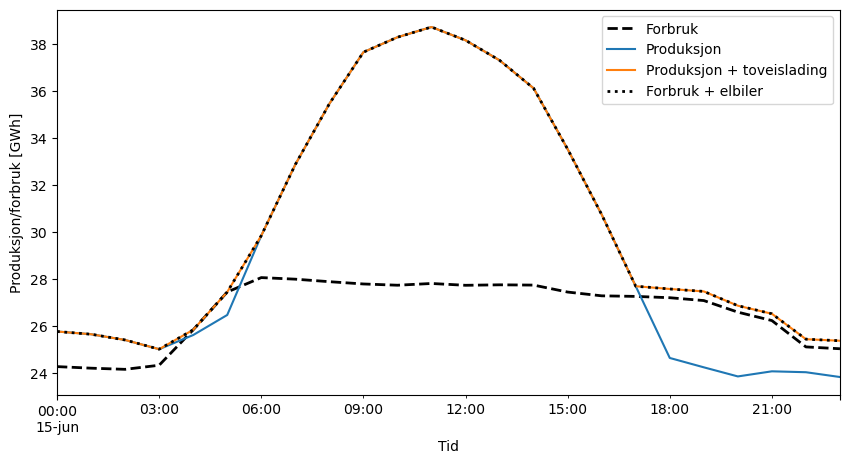

In [242]:
fig, ax=plt.subplots(figsize=(7.5*(493/366),5))
pd.DataFrame((day_demand['Base demand'] + day_demand['Transmission losses'])).rename(columns={0:'Forbruk'}).plot(ax=ax, linewidth=linewidth, color='Black', linestyle='--')


#day_gen_new = pd.DataFrame()
#day_gen_new['Vannkraft'] = day_gen['Hydropower run-of-river'] # + day_gen['Hydropower reservoir'] + day_gen['Pumped hydro'] # + day_gen['Stationary batteries']
#day_gen_new['Vindkraft'] = day_gen['Onshore wind'] + day_gen['Fixed offshore wind'] + day_gen['Floating offshore wind']
#day_gen_new['Solkraft'] = day_gen['Solar PV']
#day_gen_new.plot(stacked=True, color={'Vindkraft':'darkgreen','Solkraft':'orange','Vannkraft':'blue'}, alpha=0.5, ax=ax)
day_gen.drop(columns=['Stationary batteries', 'Vehicle to grid']).sum(axis=1).rename('Produksjon').plot(legend=True, ax=ax)
day_gen.drop(columns=['Stationary batteries']).sum(axis=1).rename('Produksjon + toveislading').plot(legend=True, ax=ax)

pd.DataFrame((day_demand['Base demand'] + day_demand['Transmission losses'] + day_demand['Flexible EV charging'])).rename(columns={0:'Forbruk + elbiler'}).plot(ax=ax, linewidth=linewidth, color='Black', linestyle=':')

plt.xlabel('Tid')
plt.ylabel('Produksjon/forbruk [GWh]')
plt.show()

# Map

New shapefile from: https://kartkatalog.geonorge.no/metadata/norske-fylker-og-kommuner-illustrasjonsdata-2021-klippet-etter-kyst/f08fca3c-33ee-49b9-be9f-028ebba5e460

In [2]:
norge = gpd.read_file("Basisdata_0000_Norge_25833_NorskeFylkerKommunerIllustrasjonsdata2021_GeoJSON/fylker2021.json").sort_values('Fylkesnummer').to_crs('EPSG:3035')
norge['code'] = 'NO' + (norge['Fylkesnummer'])
norge = norge.set_index('code')
norge.index.name = None
norge = norge.rename(columns={'Fylkesnavn':'name'})
norge = norge[['name', 'geometry']]
norge.loc['NO50', 'name'] = 'Trøndelag'
norge.loc['NO54', 'name'] = 'Troms og Finnmark'

In [3]:
norge

,name,geometry
NO03,Oslo,"MULTIPOLYGON (((4362985.405 4085235.735, 43630..."
NO11,Rogaland,"MULTIPOLYGON (((4106390.081 3914707.335, 41062..."
NO15,Møre og Romsdal,"MULTIPOLYGON (((4124724.084 4335648.442, 41247..."
NO18,Nordland,"MULTIPOLYGON (((4431794.089 4666830.15, 443183..."
NO30,Viken,"MULTIPOLYGON (((4371417.521 3984294.812, 43714..."
NO34,Innlandet,"MULTIPOLYGON (((4426411.108 4084986.055, 44264..."
NO38,Vestfold og Telemark,"MULTIPOLYGON (((4285106.207 3964018.492, 42850..."
NO42,Agder,"MULTIPOLYGON (((4176977.709 3875619.518, 41769..."
NO46,Vestland,"MULTIPOLYGON (((4050909.822 4054183.532, 40507..."
NO50,Trøndelag,"MULTIPOLYGON (((4235137.492 4445662.592, 42351..."


<Axes: >

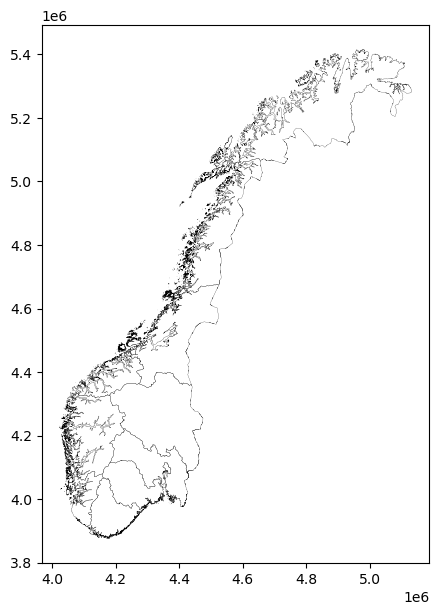

In [4]:
norge.boundary.plot(linewidth=0.15, color='black', figsize=(5,10))

Shapefile from: https://ec.europa.eu/eurostat/web/gisco/geodata/statistical-units/territorial-units-statistics

NUTS codelist: https://www.ssb.no/en/klass/klassifikasjoner/508/versjon/1371/koder

In [5]:
europe = gpd.read_file("Norway_NUTS_shp/NUTS_RG_01M_2021_3035.shp")
norway = europe[europe.CNTR_CODE == 'NO'].drop(index = [26,1786,1846,1847,1962,1985,1986,2005,2007,2008,2009])
# norway['index'] = ['NO-42','NO-38','NO-34','NO-30','NO-46','NO-50','NO-54','NO-11','NO-03','NO-15','NO-18']
norway['index'] = ['NO42', 'NO38', 'NO34', 'NO30', 'NO46', 'NO50', 'NO54', 'NO11', 'NO03', 'NO15', 'NO18']
# norway['name'] = ['Agder','Vestfold og Telemark','Innlandet','Viken','Vestland','Trøndelag','Troms og Finnmark','Rogaland','Oslo','Møre og Romsdal','Nordland']
norway = norway.rename(columns={'NAME_LATN':'name'})
norway = norway.set_index('index')
norway.index.name = None
norway = norway.sort_index()
norway = norway[['name','geometry']]
norway

,name,geometry
NO03,Oslo,"MULTIPOLYGON (((4348352.027 4101950.219, 43518..."
NO11,Rogaland,"MULTIPOLYGON (((4133166.036 4086986.139, 41346..."
NO15,Møre og Romsdal,"MULTIPOLYGON (((4288887.706 4455478.122, 42892..."
NO18,Nordland,"MULTIPOLYGON (((4653707.077 5068110.204, 46556..."
NO30,Viken,"MULTIPOLYGON (((4237516.251 4214045.207, 42379..."
NO34,Innlandet,"POLYGON ((4368926.845 4135112.244, 4363292.213..."
NO38,Vestfold og Telemark,"MULTIPOLYGON (((4355154.878 4008523.619, 43550..."
NO42,Agder,"MULTIPOLYGON (((4163717.549 4066647.533, 41648..."
NO46,Vestland,"MULTIPOLYGON (((4071883.558 4352087.919, 40726..."
NO50,Trøndelag,"MULTIPOLYGON (((4523116.427 4674561.868, 45240..."


In [6]:
norway.crs

<Projected CRS: EPSG:3035>
Name: ETRS89-extended / LAEA Europe
Axis Info [cartesian]:
- Y[north]: Northing (metre)
- X[east]: Easting (metre)
Area of Use:
- name: Europe - European Union (EU) countries and candidates. Europe - onshore and offshore: Albania; Andorra; Austria; Belgium; Bosnia and Herzegovina; Bulgaria; Croatia; Cyprus; Czechia; Denmark; Estonia; Faroe Islands; Finland; France; Germany; Gibraltar; Greece; Hungary; Iceland; Ireland; Italy; Kosovo; Latvia; Liechtenstein; Lithuania; Luxembourg; Malta; Monaco; Montenegro; Netherlands; North Macedonia; Norway including Svalbard and Jan Mayen; Poland; Portugal including Madeira and Azores; Romania; San Marino; Serbia; Slovakia; Slovenia; Spain including Canary Islands; Sweden; Switzerland; Türkiye (Turkey); United Kingdom (UK) including Channel Islands and Isle of Man; Vatican City State.
- bounds: (-35.58, 24.6, 44.83, 84.73)
Coordinate Operation:
- name: Europe Equal Area 2001
- method: Lambert Azimuthal Equal Area
Datum: Eur

<Axes: >

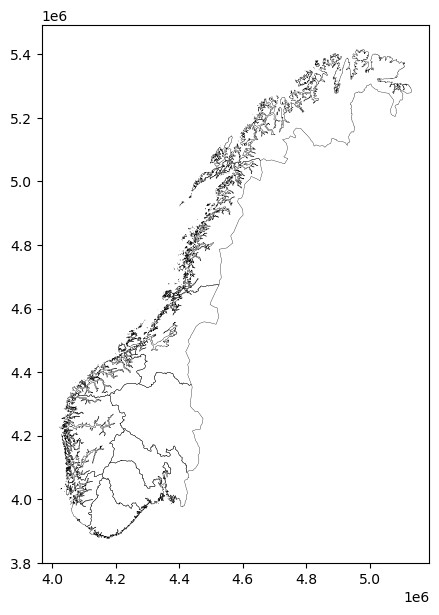

In [7]:
norway.boundary.plot(linewidth=0.25, color='black', figsize=(5,10))

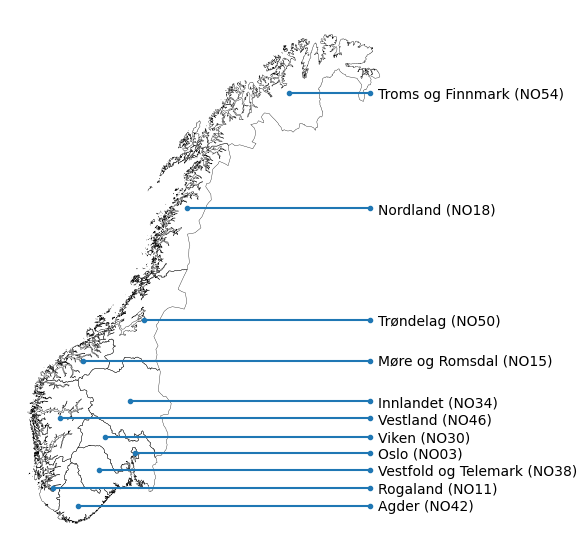

In [8]:
# colour = {'NO-03':'red', 'NO-11':'orange', 'NO-15':'green', 'NO-18':'blue', 'NO-30':'purple', 'NO-34':'teal', 'NO-38':'magenta', 'NO-42':'turquoise', 'NO-46':'peru', 'NO-50':'olive', 'NO-54':'tomato'}

ax = norway.boundary.plot(linewidth=0.25, color='black', figsize=(5,10))
center = norway.centroid
for i in norway.index:
    if i == 'NO42':
        epsilon_y = - 0.25e5
        epsilon_x = 0
    elif i == 'NO11':
        epsilon_y = - 0.2e5
        epsilon_x = 0
    elif i == 'NO30':
        epsilon_y = 0.4e5
        epsilon_x = - 0.5e5
    else:
        epsilon_y = 0
        epsilon_x = 0
    ax.plot([center[i].x + epsilon_x, 5.1*1e6],[center[i].y + epsilon_y, center[i].y + epsilon_y], marker='.', linestyle='-', alpha=1, color='tab:blue') #, color=colour[i])
    ax.text(5.125e6, center[i].y + epsilon_y, norway.name.loc[i] +' (' + str(i) + ')', horizontalalignment='left', verticalalignment='center_baseline')
plt.axis('off')
plt.show()

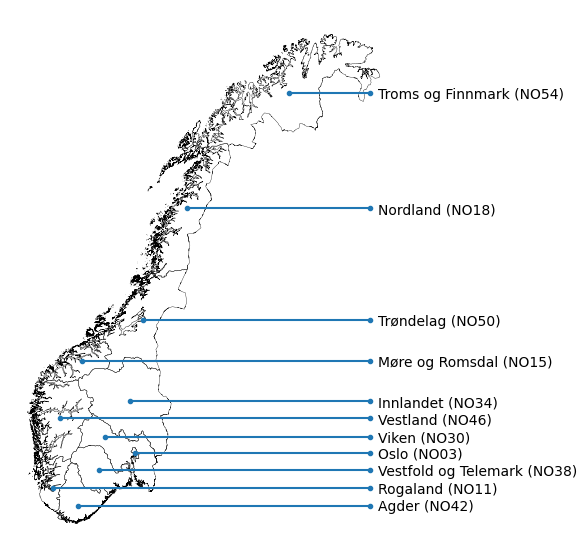

In [9]:
ax = norge.boundary.plot(linewidth=0.25, color='black', figsize=(5,10))
center = norge.centroid
for i in norge.index:
    if i == 'NO42':
        epsilon_y = - 0.25e5
        epsilon_x = 0
    elif i == 'NO11':
        epsilon_y = - 0.2e5
        epsilon_x = 0
    elif i == 'NO30':
        epsilon_y = 0.4e5
        epsilon_x = - 0.5e5
    else:
        epsilon_y = 0
        epsilon_x = 0
    ax.plot([center[i].x + epsilon_x, 5.1*1e6],[center[i].y + epsilon_y, center[i].y + epsilon_y], marker='.', linestyle='-', alpha=1, color='tab:blue') #, color=colour[i])
    ax.text(5.125e6, center[i].y + epsilon_y, norge.name.loc[i] +' (' + str(i) + ')', horizontalalignment='left', verticalalignment='center_baseline')
plt.axis('off')
plt.show()

## EV battery capacity

In [26]:
results_path='C:/Users/Tobias/OneDrive - Universitetet i Oslo/Documents/Projects/NUANCE/NUANCE results/NUANCE-results-050824/models/2010/region_0_off/results.db'


In [27]:
con = connect(results_path)
vehicles = pd.read_sql('SELECT * from par_vehicles', con, index_col='z')
con.close()

In [28]:
vehicles.value.astype('int').index

Index(['NO03', 'NO11', 'NO15', 'NO18', 'NO30', 'NO34', 'NO38', 'NO42', 'NO46',
       'NO50', 'NO54'],
      dtype='object', name='z')

In [13]:
norway2 = norway.copy()

In [29]:
norge2 = norge.copy()

In [15]:
norway2['vehicles [million]'] = vehicles.astype('int')/1e6

In [30]:
norge2['vehicles [million]'] = vehicles.astype('int')/1e6

In [31]:
import matplotlib as mpl
mpl.colormaps['viridis']([0,1])  #.resampled(8)

array([[0.267004, 0.004874, 0.329415, 1.      ],
       [0.26851 , 0.009605, 0.335427, 1.      ]])

In [18]:
norway2

,name,geometry,vehicles [million]
NO03,Oslo,"MULTIPOLYGON (((4348352.027 4101950.219, 43518...",0.324154
NO11,Rogaland,"MULTIPOLYGON (((4133166.036 4086986.139, 41346...",0.283611
NO15,Møre og Romsdal,"MULTIPOLYGON (((4288887.706 4455478.122, 42892...",0.172388
NO18,Nordland,"MULTIPOLYGON (((4653707.077 5068110.204, 46556...",0.151072
NO30,Viken,"MULTIPOLYGON (((4237516.251 4214045.207, 42379...",0.822426
NO34,Innlandet,"POLYGON ((4368926.845 4135112.244, 4363292.213...",0.263113
NO38,Vestfold og Telemark,"MULTIPOLYGON (((4355154.878 4008523.619, 43550...",0.266854
NO42,Agder,"MULTIPOLYGON (((4163717.549 4066647.533, 41648...",0.187489
NO46,Vestland,"MULTIPOLYGON (((4071883.558 4352087.919, 40726...",0.351529
NO50,Trøndelag,"MULTIPOLYGON (((4523116.427 4674561.868, 45240...",0.278712


In [32]:
norge2

,name,geometry,vehicles [million]
NO03,Oslo,"MULTIPOLYGON (((4362985.405 4085235.735, 43630...",0.324154
NO11,Rogaland,"MULTIPOLYGON (((4106390.081 3914707.335, 41062...",0.283611
NO15,Møre og Romsdal,"MULTIPOLYGON (((4124724.084 4335648.442, 41247...",0.172388
NO18,Nordland,"MULTIPOLYGON (((4431794.089 4666830.15, 443183...",0.151072
NO30,Viken,"MULTIPOLYGON (((4371417.521 3984294.812, 43714...",0.822426
NO34,Innlandet,"MULTIPOLYGON (((4426411.108 4084986.055, 44264...",0.263113
NO38,Vestfold og Telemark,"MULTIPOLYGON (((4285106.207 3964018.492, 42850...",0.266854
NO42,Agder,"MULTIPOLYGON (((4176977.709 3875619.518, 41769...",0.187489
NO46,Vestland,"MULTIPOLYGON (((4050909.822 4054183.532, 40507...",0.351529
NO50,Trøndelag,"MULTIPOLYGON (((4235137.492 4445662.592, 42351...",0.278712


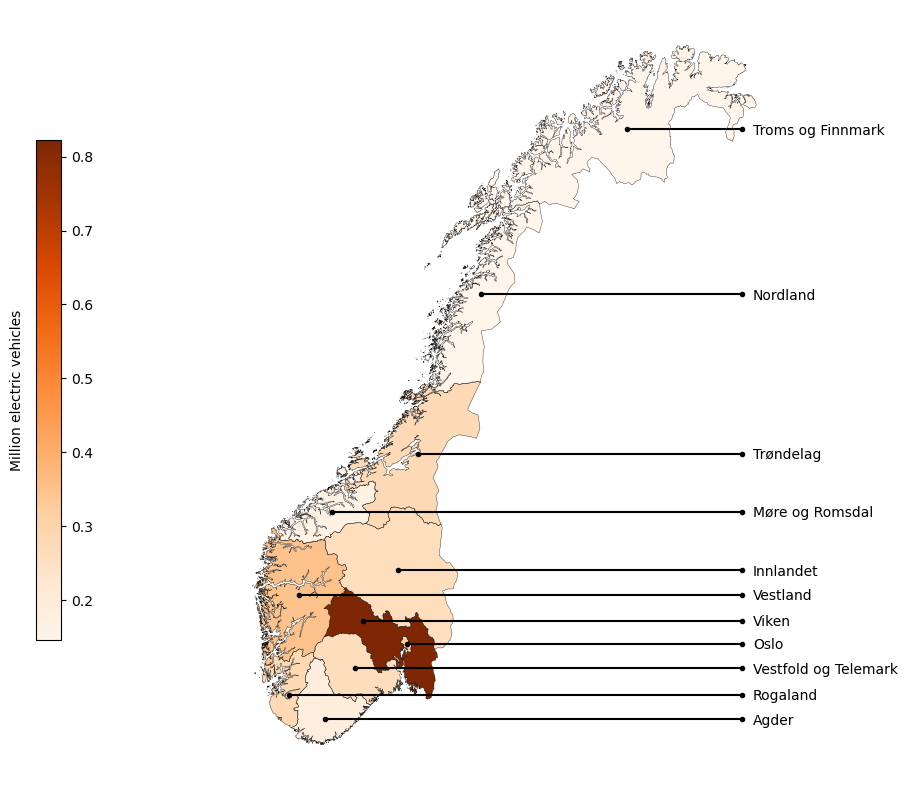

In [137]:
ax = norway2.plot('vehicles [million]', legend=True, cmap='Oranges', figsize=(10,10)) #, vmin=0.1, vmax=1)
norway2.boundary.plot(linewidth=0.25, color='black', ax=ax)
plt.gcf().get_axes()[1].set_position((0,0.25,0.5,0.5))
plt.gcf().get_axes()[1].set_ylabel('Million electric vehicles', labelpad=-60)
# plt.gcf().get_axes()[1]

center = norway.centroid
for i in norway.index:
    if i == 'NO42':
        epsilon_y = - 0.25e5
        epsilon_x = 0
    elif i == 'NO11':
        epsilon_y = - 0.2e5
        epsilon_x = 0
    elif i == 'NO30':
        epsilon_y = 0.4e5
        epsilon_x = - 0.5e5
    else:
        epsilon_y = 0
        epsilon_x = 0
    ax.plot([center[i].x + epsilon_x, 5.1*1e6],[center[i].y + epsilon_y, center[i].y + epsilon_y], marker='.', linestyle='-', alpha=1, color='black') #, color=colour[i])
    ax.text(5.125e6, center[i].y + epsilon_y, norway.name.loc[i], horizontalalignment='left', verticalalignment='center_baseline')
plt.axis('off')

plt.savefig('map_zones+EVs.svg', transparent=True, bbox_inches="tight")

plt.show()

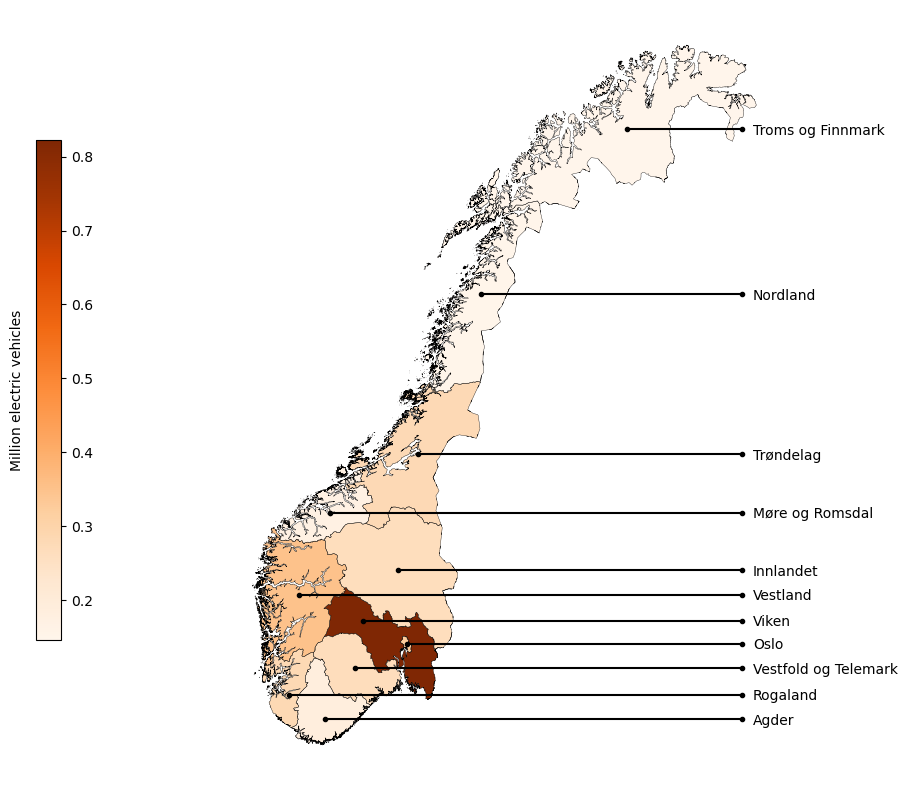

In [33]:
ax = norge2.plot('vehicles [million]', legend=True, cmap='Oranges', figsize=(10,10)) #, vmin=0.1, vmax=1)
norge2.boundary.plot(linewidth=0.25, color='black', ax=ax)
plt.gcf().get_axes()[1].set_position((0,0.25,0.5,0.5))
plt.gcf().get_axes()[1].set_ylabel('Million electric vehicles', labelpad=-60)
# plt.gcf().get_axes()[1]

center = norge.centroid
for i in norge.index:
    if i == 'NO42':
        epsilon_y = - 0.25e5
        epsilon_x = 0
    elif i == 'NO11':
        epsilon_y = - 0.2e5
        epsilon_x = 0
    elif i == 'NO30':
        epsilon_y = 0.4e5
        epsilon_x = - 0.5e5
    else:
        epsilon_y = 0
        epsilon_x = 0
    ax.plot([center[i].x + epsilon_x, 5.1*1e6],[center[i].y + epsilon_y, center[i].y + epsilon_y], marker='.', linestyle='-', alpha=1, color='black') #, color=colour[i])
    ax.text(5.125e6, center[i].y + epsilon_y, norge.name.loc[i], horizontalalignment='left', verticalalignment='center_baseline')
plt.axis('off')

plt.savefig('map_zones+EVs(new_shp).svg', transparent=True, bbox_inches="tight")

plt.show()

---

In [171]:
daily_gen = gen.groupby(gen.index.to_series().dt.date).sum()

NameError: name 'gen' is not defined

In [172]:
daily_gen['Vehicle to grid'].plot.bar(figsize = (100,100))

NameError: name 'daily_gen' is not defined

## Generation and transmission capacities

In [61]:
cap_z = makenice(sqlite_list, "cap_z").query("level_2 == 'level'")
store_z = makenice(sqlite_list, "storage_pcap_z").query("level_2 == 'level' and technology == 'Li-ion-8'")
# cap_z[cap_z.gencap < 0.01] = 0
# cap_z

100%|██████████| 42/42 [00:00<00:00, 149.46it/s]


In [62]:
V2G = 'ON'
participation = '100'
technologies = ['Solar', 'Windoffshore', 'Windoffshorefloating', 'Windonshore', 'HydroRes', 'HydroRoR']

In [63]:
pies = {}
for i in ['NO11','NO15','NO18','NO34','NO38','NO42','NO46','NO50','NO54']:
#    z = i[:2] + i[-2:]
#    data = cap_z.query("participation == @participation and V2G == @V2G and zone ==@i and technology in @technologies")
    data = pd.concat([cap_z.query("participation == @participation and V2G == @V2G and zone ==@i and technology in @technologies").gencap, store_z.query("participation == @participation and V2G == @V2G and zone ==@i").storepcaptotz])
    pies[i] = plt.pie(data.values, labels = ['HydroRes', 'HydroRoR', 'Solar', 'Windoffshore', 'Windoffshorefloating', 'Windonshore', 'Li-ion-8'], colors = ['blue', 'cornflowerblue', 'orange', 'darkcyan', 'darkturquoise', 'darkgreen', 'red'])
    plt.close()

# merge NO-03 with NO-30

df_NO03 = pd.DataFrame(cap_z
        .query("participation == @participation and V2G == @V2G and zone == 'NO03'")
        .query("technology in ['Solar', 'Windoffshore', 'Windoffshorefloating', 'Windonshore', 'HydroRes', 'HydroRoR']")
        .reset_index()
        .set_index('technology')['gencap']
        )

store_NO03 = store_z.query("participation == @participation and V2G == @V2G and zone == 'NO03'").reset_index().set_index('technology')['storepcaptotz']
df_NO03.loc[store_NO03.index[0]] = store_NO03.values[0]

df_NO30 = pd.DataFrame(cap_z
        .query("participation == @participation and V2G == @V2G and zone == 'NO30'")
        .query("technology in ['Solar', 'Windoffshore', 'Windoffshorefloating', 'Windonshore', 'HydroRes', 'HydroRoR']")
        .reset_index()
        .set_index('technology')['gencap']
        )

store_NO30 = store_z.query("participation == @participation and V2G == @V2G and zone == 'NO30'").reset_index().set_index('technology')['storepcaptotz']
df_NO30.loc[store_NO30.index[0]] = store_NO30.values[0]

pies['NO30'] = plt.pie((df_NO03 + df_NO30).values.T[0], labels = ['HydroRes', 'HydroRoR', 'Solar', 'Windoffshore', 'Windoffshorefloating', 'Windonshore', 'Li-ion-8'], colors = ['blue', 'cornflowerblue', 'orange', 'darkcyan', 'darkturquoise', 'darkgreen', 'red'])
plt.close()

In [64]:
cap_tot = {}
for i in ['NO03','NO11','NO15','NO18','NO30','NO34','NO38','NO42','NO46','NO50','NO54']:
    cap_tot[i] = cap_z.query("participation == @participation and V2G == @V2G and zone ==@i and technology in @technologies").values.T[0].sum()

# merge NO-03 with NO-30

cap_tot['NO30'] = cap_tot['NO03'] + cap_tot['NO30']
cap_tot.pop('NO03')

np.float64(1.0247000343286858)

In [65]:
cap_frac = {}
for i in ['NO11','NO15','NO18','NO30','NO34','NO38','NO42','NO46','NO50','NO54']:
    cap_frac[i] = cap_tot[i]/sum(cap_tot.values())

In [66]:
trans_cap = makenice(sqlite_list, "trans_cap")

100%|██████████| 42/42 [00:00<00:00, 156.70it/s]


In [67]:
trans = trans_cap.query("participation == @participation and V2G == @V2G and level_2 == 'level'")
trans_tot = trans.values.sum()

In [68]:
# transmission capacities are duplicated as the capacity is given in both directions. Here only one direction is selected.

trans_zones = [# ['NO-03', 'NO-30'],
               ['NO11', 'NO38'],
               ['NO11', 'NO42'],
               ['NO11', 'NO46'],
               ['NO15', 'NO34'],
               ['NO15', 'NO46'],
               ['NO15', 'NO50'],
               ['NO18', 'NO50'],
               ['NO18', 'NO54'],
               ['NO30', 'NO34'],
               ['NO30', 'NO38'],
               ['NO30', 'NO46'],
               ['NO34', 'NO46'],
               ['NO34', 'NO50'],
               ['NO38', 'NO42'],
               ['NO38', 'NO46']]

In [58]:
center = norway.centroid
center = center.drop(index=['NO03'])

# to adjust the position of the pie charts (and the end/start points of the transmission lines)

center['NO11'] = shp.Point(center['NO11'].x - 10000, center['NO11'].y)
center['NO30'] = shp.Point(center['NO30'].x + 50000, center['NO30'].y)
center['NO42'] = shp.Point(center['NO42'].x, center['NO42'].y - 20000)

In [69]:
center = norge.centroid
center = center.drop(index=['NO03'])

# to adjust the position of the pie charts (and the end/start points of the transmission lines)

center['NO11'] = shp.Point(center['NO11'].x - 10000, center['NO11'].y)
center['NO30'] = shp.Point(center['NO30'].x + 50000, center['NO30'].y)
center['NO42'] = shp.Point(center['NO42'].x, center['NO42'].y - 20000)

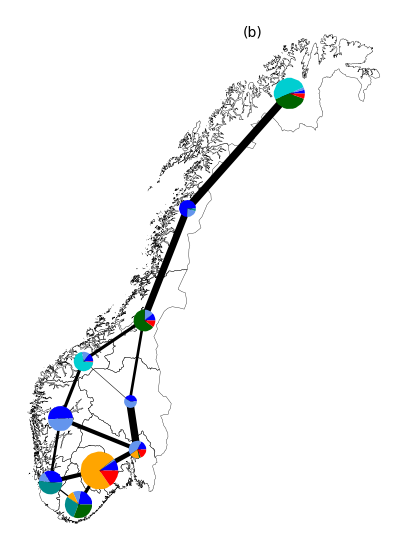

In [57]:
fig, ax = plt.subplots(1,1, figsize=(5,10))

norway.boundary.plot(ax=ax, zorder=1, linewidth=0.25, color='black')

marker_size = 3000

for i in ['NO11','NO15','NO18','NO30','NO34','NO38','NO42','NO46','NO50','NO54']:
    for j in range(7):
        ax.scatter(
            center.x[i], center.y[i], marker=(pies[i][0][j].get_path().vertices.tolist()), 
            s=marker_size*((np.abs(pies[i][0][j].get_path().vertices.tolist()).max())**2)*cap_frac[i], 
            zorder=100, 
            facecolor = ['blue', 'cornflowerblue', 'orange', 'darkcyan', 'darkturquoise', 'darkgreen', 'red'][j],
            linewidths=0
            )

# why the (np.abs(pies[i][0][j].get_path().vertices.tolist()).max())**2 ?? This is based on https://matplotlib.org/2.2.5/gallery/api/scatter_piecharts.html to make the pie charts into perfect circles.

linewidth = 75
trans_color = 'black'

for i in trans_zones:
    plt.plot([center[i[0]].x, center[i[1]].x], [center[i[0]].y, center[i[1]].y], 
             linewidth=(linewidth*trans.query("Zone_1 == '" + i[0][:2] + i[0][-2:]  + "' and Zone_2 == '" + i[1][:2] + i[1][-2:]  + "'").values[0][0]/trans_tot), 
             color=trans_color
             )

handles = pies['NO30'][0].copy()
handles.append(plt.plot([center['NO11'].x, center['NO38'].x], [center['NO11'].y, center['NO38'].y], color='black', linewidth=3)[0])
labels = ['Hydropower reservoir', 'Hydropower run-of-river', 'Solar PV', 'Fixed offshore wind', 'Floating offshore wind', 'Onshore wind', 'Stationary batteries', 'Transmission']
#ax.legend(handles,labels,loc='lower right',title='Capacities',fontsize=9)

plt.axis('off')

plt.text(0.6,0.95,'(b)', transform=ax.transAxes)
#plt.title('Vehicle-to-grid')

plt.savefig('100Flex_map.svg', transparent=True, bbox_inches="tight")

plt.show()

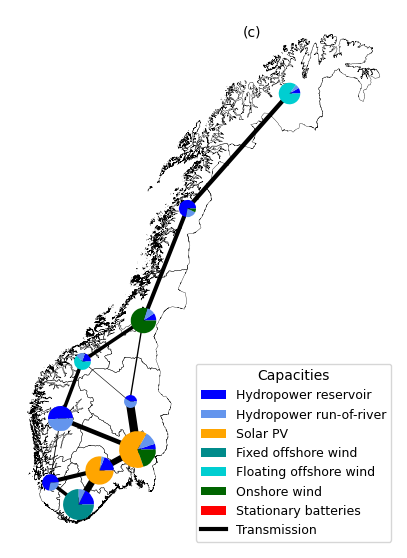

In [70]:
fig, ax = plt.subplots(1,1, figsize=(5,10))

norge.boundary.plot(ax=ax, zorder=1, linewidth=0.25, color='black')

marker_size = 3000

for i in ['NO11','NO15','NO18','NO30','NO34','NO38','NO42','NO46','NO50','NO54']:
    for j in range(7):
        ax.scatter(
            center.x[i], center.y[i], marker=(pies[i][0][j].get_path().vertices.tolist()), 
            s=marker_size*((np.abs(pies[i][0][j].get_path().vertices.tolist()).max())**2)*cap_frac[i], 
            zorder=100, 
            facecolor = ['blue', 'cornflowerblue', 'orange', 'darkcyan', 'darkturquoise', 'darkgreen', 'red'][j],
            linewidths=0
            )

# why the (np.abs(pies[i][0][j].get_path().vertices.tolist()).max())**2 ?? This is based on https://matplotlib.org/2.2.5/gallery/api/scatter_piecharts.html to make the pie charts into perfect circles.

linewidth = 75
trans_color = 'black'

for i in trans_zones:
    plt.plot([center[i[0]].x, center[i[1]].x], [center[i[0]].y, center[i[1]].y], 
             linewidth=(linewidth*trans.query("Zone_1 == '" + i[0][:2] + i[0][-2:]  + "' and Zone_2 == '" + i[1][:2] + i[1][-2:]  + "'").values[0][0]/trans_tot), 
             color=trans_color
             )

handles = pies['NO30'][0].copy()
handles.append(plt.plot([center['NO11'].x, center['NO38'].x], [center['NO11'].y, center['NO38'].y], color='black', linewidth=3)[0])
labels = ['Hydropower reservoir', 'Hydropower run-of-river', 'Solar PV', 'Fixed offshore wind', 'Floating offshore wind', 'Onshore wind', 'Stationary batteries', 'Transmission']
ax.legend(handles,labels,loc='lower right',title='Capacities',fontsize=9)

plt.axis('off')

plt.text(0.6,0.95,'(c)', transform=ax.transAxes)
#plt.title('Vehicle-to-grid')

plt.savefig('100V2G_map(new_shp).svg', transparent=True, bbox_inches="tight")

plt.show()

# Analysis new

In [ ]:
from pathlib import Path

In [ ]:
list(Path("C:/Users/Tobias/Downloads/NUANCE/NUANCE-results-050824/").glob('**/*.db'))

# Archive

In [58]:
def percent_change(data):
    results = (((data - data[0])/data[0])*100).round(1)
    return results

In [59]:
# shapefile of Norwegian counties

shapefile = shpreader.natural_earth(resolution='10m',
                                      category='cultural',
                                      name='admin_1_states_provinces')

world = gpd.read_file(shapefile)

Norway = world[world.iso_a2=="NO"]
Norway = Norway[["iso_3166_2","name","geometry"]]
Norway = Norway.set_index('iso_3166_2').drop(['NO-21', 'NO-X01~'])

In [60]:
Trøndelag = gpd.GeoDataFrame([{'name':'Trøndelag', 'geometry':Norway.loc[['NO-17', 'NO-16']].unary_union}], index=['NO-50'])
TromsFinnmark = gpd.GeoDataFrame([{'name':'Troms og Finnmark', 'geometry':Norway.loc[['NO-19', 'NO-20']].unary_union}], index=['NO-54'])
Vestland = gpd.GeoDataFrame([{'name':'Vestland', 'geometry':Norway.loc[['NO-12', 'NO-14']].unary_union}], index=['NO-46'])
Viken = gpd.GeoDataFrame([{'name':'Viken', 'geometry':Norway.loc[['NO-02', 'NO-06', 'NO-01']].unary_union}], index=['NO-30'])
Innlandet = gpd.GeoDataFrame([{'name':'Innlandet', 'geometry':Norway.loc[['NO-04', 'NO-05']].unary_union}], index=['NO-34'])
VestfoldTelemark = gpd.GeoDataFrame([{'name':'Vestfold og Telemark', 'geometry':Norway.loc[['NO-07', 'NO-08']].unary_union}], index=['NO-38'])
Agder = gpd.GeoDataFrame([{'name':'Agder', 'geometry':Norway.loc[['NO-09', 'NO-10']].unary_union}], index=['NO-42'])
Nordland = gpd.GeoDataFrame([{'name':'Nordland', 'geometry':Norway.loc[['NO-18']].explode().drop(('NO-18',25)).unary_union}], index=['NO-18'])

Norway = Norway.drop(['NO-17', 'NO-16', 'NO-19', 'NO-20', 'NO-12', 'NO-14', 'NO-02', 'NO-06', 'NO-01', 'NO-04', 'NO-05', 'NO-07', 'NO-08', 'NO-09', 'NO-10', 'NO-18'])

Norway = pd.concat([Norway, Trøndelag.set_crs(Norway.crs), TromsFinnmark.set_crs(Norway.crs), Vestland.set_crs(Norway.crs), Viken.set_crs(Norway.crs), Innlandet.set_crs(Norway.crs), VestfoldTelemark.set_crs(Norway.crs), Agder.set_crs(Norway.crs), Nordland.set_crs(Norway.crs)])

Norway = Norway.sort_index()

C:\Users\Tobias\AppData\Local\Temp\ipykernel_15980\2624195649.py:8: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  Nordland = gpd.GeoDataFrame([{'name':'Nordland', 'geometry':Norway.loc[['NO-18']].explode().drop(('NO-18',25)).unary_union}], index=['NO-18'])
